# DS317.R11 – Notebook kiểm chứng nhanh cho Bản đề xuất đề tài

Đề tài: Dự báo doanh thu 4 tuần theo danh mục cho doanh nghiệp thời trang thương mại điện tử (dữ liệu Datathon 2026).

Mọi con số trong Bản đề xuất được tính từ notebook này. Cách chạy: đặt `DATA_DIR` ở Phần 0 tới thư mục chứa các file CSV, rồi chạy **Restart and run all**.

| Phần | Nội dung | Dùng cho mục trong Bản đề xuất |
| --- | --- | --- |
| 0 | Cấu hình đường dẫn dữ liệu | – |
| A | Quy mô, cấu trúc, tính riêng tư; kiểm chứng nhanh PA2 | 1.1, 1.2 (Quy mô, Cấu trúc, Tính riêng tư), 4.1 (PA2) |
| B | Chất lượng và thời gian của dữ liệu | 1.2 (Chất lượng, Thời gian), 1.3 |
| C | Nhãn, chi phí của việc làm sai; kiểm chứng nhanh PA3 | 1.2 (Nhãn), 2.1, 4.1 (PA3) |
| D | Tên cột thật, quy tắc đơn hủy/trả; kiểm chứng nhanh PA1 | Phần 3, 4.1 (PA1) |


# Phần 0. Cấu hình đường dẫn dữ liệu

In [ ]:
import os

from pathlib import Path
# Tự tìm thư mục gốc repo (chứa data/raw). Máy khác/Colab: đặt biến môi trường DS317_DATA_DIR.
_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data' / 'raw').is_dir()), None)
DATA_DIR = os.environ.get('DS317_DATA_DIR') or (str(_ROOT / 'data' / 'raw' / 'datathon-2026-round-1') if _ROOT else '/content/sample_data')
PROJECT_DIR = str(_ROOT) if _ROOT else os.getcwd()

# Dữ liệu do BTC Datathon 2026 cung cấp trên Kaggle (datathon-2026-round-1).
# Theo quy định BTC, dữ liệu không được chia sẻ ra bên ngoài nên không đính kèm notebook.
# Sửa DATA_DIR tới thư mục chứa các file CSV đã tải về.

OUT_DIR_ALL = os.path.join(PROJECT_DIR, 'outputs')
os.makedirs(OUT_DIR_ALL, exist_ok=True)

assert os.path.exists(os.path.join(DATA_DIR, 'order_items.csv')), f'Không thấy dữ liệu trong {DATA_DIR}'
print('Dữ liệu:', DATA_DIR)
print('Kết quả xuất ra:', OUT_DIR_ALL)


# Phần A. Quy mô, cấu trúc, tính riêng tư và kiểm chứng nhanh PA2

Phụ trách: Tường Vi

## 2. Quy mô: số dòng × số cột × dung lượng

In [ ]:
import os
import pandas as pd

# Define TABLES based on the available CSV files
TABLES = [
    'products', 'orders', 'inventory', 'returns', 'reviews',
    'promotions', 'sample_submission', 'payments', 'web_traffic',
    'shipments', 'geography', 'customers', 'sales', 'order_items'
]

# Define path_of function to construct file paths
# DATA_DIR lấy từ Phần 0
def path_of(table_name):
    return os.path.join(DATA_DIR, table_name + '.csv')

# Define OUT_DIR for output files
OUT_DIR = OUT_DIR_ALL + '/'

data, rows = {}, []
for t in TABLES:
    p = path_of(t)
    df = pd.read_csv(p, low_memory=False)
    data[t] = df
    b = os.path.getsize(p)
    rows.append({'bảng': t, 'file': os.path.basename(p), 'số dòng': len(df), 'số cột': df.shape[1],
                 'MB (1024²)': round(b/1024**2, 2), 'MB (10⁶)': round(b/1e6, 2)})
scale = pd.DataFrame(rows)
tot = {'bảng':'TỔNG','file':'','số dòng':scale['số dòng'].sum(),'số cột':scale['số cột'].sum(),
       'MB (1024²)':round(scale['MB (1024²)'].sum(),2),'MB (10⁶)':round(scale['MB (10⁶)'].sum(),2)}
scale = pd.concat([scale, pd.DataFrame([tot])], ignore_index=True)
scale.to_csv(OUT_DIR + 'quy_mo_14_bang.csv', index=False)
scale

,bảng,file,số dòng,số cột,MB (1024²),MB (10⁶)
0,products,products.csv,2412,8,0.19,0.20
1,orders,orders.csv,646945,8,43.83,45.96
2,inventory,inventory.csv,60247,17,5.41,5.67
3,returns,returns.csv,39939,7,2.18,2.28
4,reviews,reviews.csv,113551,7,6.48,6.79
5,promotions,promotions.csv,50,10,0.00,0.00
6,sample_submission,sample_submission.csv,548,3,0.02,0.02
7,payments,payments.csv,646945,4,17.53,18.38
8,web_traffic,web_traffic.csv,3652,7,0.20,0.21
9,shipments,shipments.csv,566067,4,18.84,19.76


## Đếm lại các con số được nêu trong docx

In [ ]:
oi, o = data['order_items'], data['orders']
print('order_items dòng      :', f"{len(oi):,}")
print('số đơn (orders)       :', f"{o['order_id'].nunique():,}")
print('tổng số lượng (Σ qty) :', f"{oi['quantity'].sum():,}")
print('products (SKU)        :', f"{len(data['products']):,}")
print('inventory dòng / SP   :', f"{len(data['inventory']):,} / {data['inventory']['product_id'].nunique():,}")
print('inventory số mốc snapshot:', data['inventory']['snapshot_date'].nunique(),
      '|', data['inventory']['snapshot_date'].min(), '→', data['inventory']['snapshot_date'].max())
print('sales ngày            :', f"{len(data['sales']):,}", '|', data['sales']['Date'].min(), '→', data['sales']['Date'].max())
print('web_traffic ngày      :', f"{len(data['web_traffic']):,}", '|', data['web_traffic']['date'].min(), '→', data['web_traffic']['date'].max())
print('customers / reviews / shipments:', f"{len(data['customers']):,} / {len(data['reviews']):,} / {len(data['shipments']):,}")

order_items dòng      : 714,669
số đơn (orders)       : 646,945
tổng số lượng (Σ qty) : 3,213,143
products (SKU)        : 2,412
inventory dòng / SP   : 60,247 / 1,624
inventory số mốc snapshot: 126 | 2012-07-31 → 2022-12-31
sales ngày            : 3,833 | 2012-07-04 → 2022-12-31
web_traffic ngày      : 3,652 | 2013-01-01 → 2022-12-31
customers / reviews / shipments: 121,930 / 113,551 / 566,067


### Sơ đồ 14 bảng

#### Mermaid trên draw.io

erDiagram
    customers ||--o{ orders : "đặt"
    geography ||--o{ customers : "zip"
    geography ||--o{ orders : "zip giao hàng"
    orders ||--|{ order_items : "gồm"
    orders ||--|| payments : "thanh toán"
    orders ||--o| shipments : "giao hàng"
    orders ||--o{ returns : "trả hàng"
    orders ||--o{ reviews : "được đánh giá"
    products ||--o{ order_items : "được bán"
    products ||--o{ inventory : "tồn kho tháng"
    products ||--o{ returns : "bị trả"
    products ||--o{ reviews : "được đánh giá"
    customers ||--o{ reviews : "viết"
    promotions |o--o{ order_items : "promo_id"
    promotions |o--o{ order_items : "promo_id_2"
    sales ||..o{ orders : "Date = order_date"
    sales ||..o| web_traffic : "Date = date"

    customers {
        int customer_id PK
        int zip FK
        string city
        date signup_date
        string gender
        string age_group
        string acquisition_channel
    }
    geography {
        int zip PK
        string city
        string region
        string district
    }
    products {
        int product_id PK
        string product_name
        string category
        string segment
        string size
        string color
        float price
        float cogs
    }
    promotions {
        string promo_id PK
        string promo_name
        string promo_type
        float discount_value
        date start_date
        date end_date
        string applicable_category
        string promo_channel
        int stackable_flag
        int min_order_value
    }
    orders {
        int order_id PK
        date order_date
        int customer_id FK
        int zip FK
        string order_status
        string payment_method
        string device_type
        string order_source
    }
    order_items {
        int order_id FK "khóa ghép, 16 cặp trùng"
        int product_id FK "khóa ghép"
        int quantity
        float unit_price
        float discount_amount
        string promo_id FK "có thể rỗng"
        string promo_id_2 FK "có thể rỗng"
    }
    payments {
        int order_id PK, FK
        string payment_method
        float payment_value
        int installments
    }
    shipments {
        int order_id PK, FK
        date ship_date
        date delivery_date
        float shipping_fee
    }
    returns {
        string return_id PK
        int order_id FK
        int product_id FK
        date return_date
        string return_reason
        int return_quantity
        float refund_amount
    }
    reviews {
        string review_id PK
        int order_id FK
        int product_id FK
        int customer_id FK
        date review_date
        int rating
        string review_title
    }
    inventory {
        date snapshot_date PK
        int product_id PK, FK
        int stock_on_hand
        int units_received
        int units_sold
        int stockout_days
        float days_of_supply
        float fill_rate
        int stockout_flag
        int overstock_flag
        int reorder_flag
        float sell_through_rate
        string product_name
        string category
        string segment
        int year
        int month
    }
    sales {
        date Date PK
        float Revenue
        float COGS
    }
    web_traffic {
        date date PK
        int sessions
        int unique_visitors
        int page_views
        float bounce_rate
        float avg_session_duration_sec
        string traffic_source
    }
    sample_submission {
        date Date PK
        float Revenue
        float COGS
    }

## 4. Tính riêng tư của `customers`

customers gồm 7 cột: customer_id, zip, city, signup_date, gender, age_group, acquisition_channel.

In [ ]:
cust = data['customers']
print('Các cột:', list(cust.columns))
print('Cột trông giống tên/email/SĐT/địa chỉ:',
      [c for c in cust.columns if any(k in c.lower() for k in ['name','mail','phone','addr','street','tel'])])
prof = pd.DataFrame({'kiểu': cust.dtypes.astype(str), 'số giá trị khác nhau': cust.nunique(),
                     'thiếu': cust.isna().sum(), 'ví dụ': cust.iloc[0]})
display(prof)
print(cust['gender'].value_counts().to_dict())
print(cust['age_group'].value_counts().to_dict())
print(cust['acquisition_channel'].value_counts().to_dict())
print('signup_date:', cust['signup_date'].min(), '→', cust['signup_date'].max())
geo = data['geography']
print('customers.city khớp geography.city:', (cust.merge(geo, on='zip', suffixes=('','_g'))
                                              .eval('city == city_g')).mean())

Các cột: ['customer_id', 'zip', 'city', 'signup_date', 'gender', 'age_group', 'acquisition_channel']
Cột trông giống tên/email/SĐT/địa chỉ: []


,kiểu,số giá trị khác nhau,thiếu,ví dụ
customer_id,int64,121930,0,1
zip,int64,31491,0,15201
city,object,42,0,Hai Phong
signup_date,object,3941,0,2021-12-30
gender,object,3,0,Female
age_group,object,5,0,35-44
acquisition_channel,object,6,0,social_media


{'Female': 59640, 'Male': 57457, 'Non-binary': 4833}
{'25-34': 36342, '35-44': 31920, '45-54': 23172, '18-24': 17039, '55+': 13457}
{'organic_search': 36450, 'social_media': 24448, 'paid_search': 24285, 'email_campaign': 14674, 'referral': 12270, 'direct': 9803}
signup_date: 2012-01-17 → 2022-12-31
customers.city khớp geography.city: 1.0


In [ ]:
# Nguy cơ nhận dạng lại: kích thước nhóm k khi kết hợp các cột bán định danh
def k_anon(cols):
    s = cust.groupby(cols).size().rename('k').reset_index()
    per = cust.merge(s, on=cols)['k']
    return {'tổ hợp cột': ' + '.join(cols), 'số nhóm': len(s), 'k nhỏ nhất': int(s['k'].min()),
            'bản ghi duy nhất (k=1)': int((per == 1).sum()), '% duy nhất': round((per == 1).mean()*100, 2),
            '% có k<5': round((per < 5).mean()*100, 2)}
priv = pd.DataFrame([k_anon(c) for c in [['city','gender','age_group'], ['zip'], ['zip','gender','age_group'],
                                        ['gender','age_group','signup_date'], ['zip','gender','age_group','signup_date']]])
priv.to_csv(OUT_DIR + 'rui_ro_nhan_dang_lai.csv', index=False)
priv

,tổ hợp cột,số nhóm,k nhỏ nhất,bản ghi duy nhất (k=1),% duy nhất,% có k<5
0,city + gender + age_group,630,2,0,0.00,0.04
1,zip,31491,1,322,0.26,64.23
2,zip + gender + age_group,103840,1,87380,71.66,100.00
3,gender + age_group + signup_date,36493,1,10701,8.78,46.52
4,zip + gender + age_group + signup_date,121921,1,121912,99.99,100.00


In [ ]:
# Kiểm tra signup_date có đáng tin không: đơn đặt trước ngày đăng ký
m = data['orders'].merge(cust[['customer_id','signup_date']], on='customer_id')
before = pd.to_datetime(m['order_date']) < pd.to_datetime(m['signup_date'])
print(f'Đơn đặt trước ngày đăng ký: {before.sum():,} / {len(m):,} = {before.mean()*100:.1f}%')

Đơn đặt trước ngày đăng ký: 477,453 / 646,945 = 73.8%


## 5. Kiểm chứng nhanh PA2 — số lượng theo SKU × tuần
**Định nghĩa (khớp với 2.2 và Phần 3 của docx):**
- Tuần tính từ Thứ 2 đến Chủ nhật; mốc cắt là cuối ngày Chủ nhật.
- Dữ liệu bắt đầu Thứ 4 (2012-07-04) và kết thúc Thứ 7 (2022-12-31), nên **bỏ 2 tuần không đầy đủ** ở hai đầu. Còn tuần đầy đủ từ 2012-07-09 đến 2022-12-19 (kết thúc CN 2022-12-25).
- Biến mục tiêu PA2: Σ `quantity` theo (SKU, tuần), gán tuần theo `orders.order_date`.
- Bản chính tính **mọi trạng thái đơn** (khớp con số 3.213.143 đơn vị trong docx). Quy tắc đơn hủy/trả là việc của Văn Quyền; cell cuối chạy thử bản loại đơn `cancelled` để xem độ nhạy.
- "Đủ lịch sử" = có ít nhất 52 tuần kể từ tuần bán đầu tiên (để có lag 52 tuần), tính đến mốc cắt.
- Chia theo thời gian như 4.1: train đến hết 2020, validation 2021, test 2022 (theo năm của ngày Thứ 2 đầu tuần).

In [ ]:
import pandas as pd
import numpy as np
import time

# ==========================================
# 0. TẠO VÀ CHUẨN BỊ DỮ LIỆU df_sku_weekly
# ==========================================
# Hợp nhất chi tiết đơn hàng và đơn hàng để có ngày mua
oi_temp = data['order_items'][['order_id', 'product_id', 'quantity']]
o_temp = data['orders'][['order_id', 'order_date']]
m_df = pd.merge(oi_temp, o_temp, on='order_id')
m_df['order_date'] = pd.to_datetime(m_df['order_date'])

# Tính ngày Thứ Hai đầu tuần
m_df['week_start'] = m_df['order_date'] - pd.to_timedelta(m_df['order_date'].dt.weekday, unit='D')
full_weeks = pd.date_range(start='2012-07-09', end='2022-12-25', freq='W-MON')
m_df = m_df[(m_df['week_start'] >= full_weeks.min()) & (m_df['week_start'] <= full_weeks.max())]

# Tạo ma trận đầy đủ SKU x Tuần
all_skus = sorted(data['products']['product_id'].unique())
full_idx = pd.MultiIndex.from_product([all_skus, full_weeks], names=['sku_id', 'year_week'])
df_sku_weekly = pd.DataFrame(index=full_idx).reset_index()

# Tổng hợp doanh số thực tế
sales_agg = m_df.groupby(['product_id', 'week_start'])['quantity'].sum().reset_index()
sales_agg.columns = ['sku_id', 'year_week', 'sales']

# Kết hợp doanh số thực tế vào bảng
df_sku_weekly = pd.merge(df_sku_weekly, sales_agg, on=['sku_id', 'year_week'], how='left').fillna(0)
df_sku_weekly['year'] = df_sku_weekly['year_week'].dt.year
df_sku_weekly['week_of_year'] = df_sku_weekly['year_week'].dt.isocalendar().week.astype(int)

# Tìm tuần bán đầu tiên của mỗi SKU
first_sell = df_sku_weekly[df_sku_weekly['sales'] > 0].groupby('sku_id')['year_week'].min().reset_index()
first_sell.columns = ['sku_id', 'first_sell_week']
df_sku_weekly = pd.merge(df_sku_weekly, first_sell, on='sku_id', how='left')
df_sku_weekly['first_sell_week'] = df_sku_weekly['first_sell_week'].fillna(pd.Timestamp('2099-12-31'))

# ==========================================
# 0. ĐỊNH NGHĨA HÀM TÍNH ĐỘ ĐO (WMAPE & MAE)
# ==========================================
def calculate_wmape_mae(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    total_actual = np.sum(y_true)
    wmape = np.sum(np.abs(y_true - y_pred)) / total_actual if total_actual != 0 else np.nan
    mae = np.mean(np.abs(y_true - y_pred))

    return wmape, mae

# ==========================================
# 1. BƯỚC (1): TÍNH % TUẦN BÁN = 0 THEO SKU
# ==========================================
# Lọc các tuần từ tuần bán đầu tiên của mỗi SKU đến hết 2022 (Full Lifecycle)
df_lifecycle = df_sku_weekly[df_sku_weekly['year_week'] >= df_sku_weekly['first_sell_week']].copy()

# (1.1) % tuần bán = 0 theo chu kỳ sống (Full Lifecycle -> 72.25%)
pct_zero_lifecycle = (df_lifecycle['sales'] == 0).mean() * 100

# (1.2) % tuần bán = 0 trên toàn ma trận thô (SKU x All Weeks -> 87.79%)
pct_zero_full_matrix = (df_sku_weekly['sales'] == 0).mean() * 100

print(f"--- BƯỚC 1: TẠO BIẾN MỤC TIÊU ---")
print(f"% tuần bán = 0 (Từ tuần bán đầu tiên đến hết 2022): {pct_zero_lifecycle:.2f}%")
print(f"% tuần bán = 0 (Toàn bộ ma trận thô SKU x Weeks): {pct_zero_full_matrix:.2f}%\n")


# ==========================================
# 2. BƯỚC (2): LỌC MẪU VÀ ĐẾM SỐ MẪU
# ==========================================
# Điều kiện lọc: SKU phải đủ lịch sử >= 52 tuần kể từ tuần bán đầu tiên
sku_history_count = df_lifecycle.groupby('sku_id')['year_week'].nunique()
qualified_skus = sku_history_count[sku_history_count >= 52].index

# Tập dữ liệu Validation năm 2021 sau khi lọc SKU đủ lịch sử
val_2021_sku = df_sku_weekly[
    (df_sku_weekly['sku_id'].isin(qualified_skus)) &
    (df_sku_weekly['year'] == 2021)
].copy()

n_qualified_skus = len(qualified_skus)
n_samples_val = len(val_2021_sku)

# % tuần bán = 0 riêng trên tập Validation 2021 (PA2 Validation -> 84.2%)
pct_zero_val_2021 = (val_2021_sku['sales'] == 0).mean() * 100

print(f"--- BƯỚC 2: SỐ MẪU SAU LỌC ---")
print(f"Số SKU đủ lịch sử (>= 52 tuần): {n_qualified_skus} SKU")
print(f"Số mẫu trên Validation 2021 (SKU x Tuần): {n_samples_val} mẫu")
print(f"% tuần bán = 0 riêng trên tập Validation 2021: {pct_zero_val_2021:.2f}%\n")


# ==========================================
# 3. BƯỚC (3): CHẠY BASELINE TRÊN VALIDATION 2021
# ==========================================
start_time = time.time()

# ------------------------------------------
# Baseline A: Seasonal Naive (Lấy cùng kỳ năm ngoái - lùi 52 tuần)
# ------------------------------------------
# Ghép giá trị tuần w-52 vào năm 2021
df_2020 = df_sku_weekly[df_sku_weekly['year'] == 2020][['sku_id', 'week_of_year', 'sales']].rename(
    columns={'sales': 'pred_snaive'}
)

val_2021_sku = val_2021_sku.merge(df_2020, on=['sku_id', 'week_of_year'], how='left')
val_2021_sku['pred_snaive'] = val_2021_sku['pred_snaive'].fillna(0) # Trám 0 nếu năm 2020 chưa bán

wmape_sn, mae_sn = calculate_wmape_mae(val_2021_sku['sales'], val_2021_sku['pred_snaive'])

# ------------------------------------------
# Baseline B: Mean 4 Weeks (Trung bình 4 tuần gần nhất)
# ------------------------------------------
# Sắp xếp theo SKU và thời gian để tính trung bình động 4 tuần
df_sorted = df_sku_weekly.sort_values(['sku_id', 'year_week']).copy()
df_sorted['pred_mean_4w'] = df_sorted.groupby('sku_id')['sales'].transform(
    lambda x: x.shift(1).rolling(window=4, min_periods=1).mean()
)

val_2021_with_mean = val_2021_sku.merge(
    df_sorted[['sku_id', 'year_week', 'pred_mean_4w']],
    on=['sku_id', 'year_week'],
    how='left'
)
val_2021_with_mean['pred_mean_4w'] = val_2021_with_mean['pred_mean_4w'].fillna(0)

wmape_m4, mae_m4 = calculate_wmape_mae(val_2021_with_mean['sales'], val_2021_with_mean['pred_mean_4w'])

execution_time = time.time() - start_time

print(f"--- BƯỚC 3: KẾT QUẢ BASELINE TRÊN VALIDATION 2021 ---")
print(f"1. Seasonal Naive  -> WMAPE: {wmape_sn:.2%}, MAE: {mae_sn:.4f}")
print(f"2. Mean 4 Weeks    -> WMAPE: {wmape_m4:.2%}, MAE: {mae_m4:.4f}")
print(f"Thời gian chạy Baseline: {execution_time:.2f} giây")

--- BƯỚC 1: TẠO BIẾN MỤC TIÊU ---
% tuần bán = 0 (Từ tuần bán đầu tiên đến hết 2022): 72.25%
% tuần bán = 0 (Toàn bộ ma trận thô SKU x Weeks): 87.79%

--- BƯỚC 2: SỐ MẪU SAU LỌC ---
Số SKU đủ lịch sử (>= 52 tuần): 1515 SKU
Số mẫu trên Validation 2021 (SKU x Tuần): 78780 mẫu
% tuần bán = 0 riêng trên tập Validation 2021: 83.62%

--- BƯỚC 3: KẾT QUẢ BASELINE TRÊN VALIDATION 2021 ---
1. Seasonal Naive  -> WMAPE: 107.33%, MAE: 2.2522
2. Mean 4 Weeks    -> WMAPE: 76.64%, MAE: 1.6081
Thời gian chạy Baseline: 1.06 giây


# Phần B. Chất lượng và thời gian của dữ liệu

Phụ trách: Hải Đăng

## Kiểm chứng chất lượng và thời gian của dữ liệu

Số liệu cho ô Chất lượng, ô Thời gian (bảng 1.2) và phần chia tập (bảng 4.1) của bản đề xuất.

1. Dòng trùng
2. Giá trị thiếu
3. Giá trị mâu thuẫn
4. Thời gian và tập test 2022
5. Bảng inventory
6. SKU giá dưới 100
7. Đơn vị tiền tệ
8. Tóm tắt

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)

# DATA_DIR lấy từ Phần 0

DATE_COLS = {
    'customers': ['signup_date'], 'inventory': ['snapshot_date'], 'orders': ['order_date'],
    'promotions': ['start_date', 'end_date'], 'returns': ['return_date'], 'reviews': ['review_date'],
    'sales': ['Date'], 'shipments': ['ship_date', 'delivery_date'], 'web_traffic': ['date'],
}
TABLES = ['customers', 'geography', 'inventory', 'orders', 'order_items', 'payments', 'products',
          'promotions', 'returns', 'reviews', 'sales', 'shipments', 'web_traffic']

dfs = {t: pd.read_csv(os.path.join(DATA_DIR, f'{t}.csv'), parse_dates=DATE_COLS.get(t, []),
                      dtype={'promo_id': 'string', 'promo_id_2': 'string'})
       for t in TABLES}

orders, oi, prod, inv, s = dfs['orders'], dfs['order_items'], dfs['products'], dfs['inventory'], dfs['sales']
s = s.set_index('Date').sort_index()

pd.DataFrame({t: {'rows': len(d), 'cols': d.shape[1]} for t, d in dfs.items()}).T

,rows,cols
customers,121930,7
geography,39948,4
inventory,60247,17
orders,646945,8
order_items,714669,7
payments,646945,4
products,2412,8
promotions,50,10
returns,39939,7
reviews,113551,7


`sample_submission.csv` là file nộp bài của cuộc thi nên không đọc. `promotions` có 50 dòng (đếm bằng `wc -l` ra 49 vì dòng cuối không có ký tự xuống dòng).

## 1. Dòng trùng (ô Chất lượng)

Kiểm tra trùng nguyên dòng và trùng theo khóa của từng bảng.

In [ ]:
KEYS = {
    'customers': ['customer_id'], 'geography': ['zip'], 'inventory': ['product_id', 'snapshot_date'],
    'orders': ['order_id'], 'order_items': ['order_id', 'product_id'], 'payments': ['order_id'],
    'products': ['product_id'], 'promotions': ['promo_id'], 'returns': ['return_id'],
    'reviews': ['review_id'], 'sales': ['Date'], 'shipments': ['order_id'], 'web_traffic': ['date'],
}
dup = pd.DataFrame([{'table': t, 'key': ', '.join(k), 'rows': len(dfs[t]),
                     'dup_full_row': dfs[t].duplicated().sum(), 'dup_key': dfs[t].duplicated(k).sum()}
                    for t, k in KEYS.items()])
display(dup)
oi[oi.duplicated(['order_id', 'product_id'], keep=False)].sort_values(['order_id', 'product_id']).head(6)

,table,key,rows,dup_full_row,dup_key
0,customers,customer_id,121930,0,0
1,geography,zip,39948,0,0
2,inventory,"product_id, snapshot_date",60247,0,0
3,orders,order_id,646945,0,0
4,order_items,"order_id, product_id",714669,0,16
5,payments,order_id,646945,0,0
6,products,product_id,2412,0,0
7,promotions,promo_id,50,0,0
8,returns,return_id,39939,0,0
9,reviews,review_id,113551,0,0


,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
12233,14280,976,1,4019.47,0.0,<NA>,<NA>
12234,14280,976,2,3937.99,0.0,<NA>,<NA>
99645,113379,786,6,694.34,0.0,<NA>,<NA>
99646,113379,786,1,699.37,0.0,<NA>,<NA>
189239,215525,1859,5,1896.11,0.0,<NA>,<NA>
189240,215525,1859,5,1897.20,0.0,<NA>,<NA>


**Nhận xét**

- Không bảng nào có dòng trùng nguyên dòng.
- `order_items` có 16 dòng (8 cặp) trùng `(order_id, product_id)` nhưng khác `quantity` và `unit_price`. Đây là hai dòng hàng riêng của cùng một SKU trong một đơn, không phải nhập trùng, nên giữ nguyên.
- Mỗi dòng của `order_items` là "1 dòng hàng trong 1 đơn", không hẳn là "1 SKU trong 1 đơn".

## 2. Giá trị thiếu (ô Chất lượng, phụ lục)

Tách ba kiểu thiếu:

- ô rỗng (và xem ô rỗng đó có nghĩa là "không áp dụng" hay không);
- thiếu nguyên dòng ở các bảng theo ngày;
- bản ghi con bị thiếu.

In [ ]:
STRUCTURAL = {('order_items', 'promo_id'), ('order_items', 'promo_id_2'), ('promotions', 'applicable_category')}
missing = pd.DataFrame([{'table': t, 'column': c, 'n_null': d[c].isna().sum(),
                         'pct_null': round(d[c].isna().mean() * 100, 2),
                         'loai': 'không áp dụng' if (t, c) in STRUCTURAL else 'thiếu thật'}
                        for t, d in dfs.items() for c in d.columns if d[c].isna().any()])
print('Tổng số cột:', sum(d.shape[1] for d in dfs.values()), '| số cột có ô rỗng:', len(missing))
display(missing)

# giá trị giả dạng thiếu: chuỗi rỗng, 'unknown', ...
FAKE_NA = {'', 'unknown', 'none', 'null', 'nan', 'n/a', '-', '?'}
fake = [(t, c) for t, d in dfs.items() for c in d.select_dtypes(include=['object', 'string']).columns
        if d[c].dropna().astype(str).str.strip().str.lower().isin(FAKE_NA).any()]
print('Cột chứa chuỗi kiểu unknown/rỗng:', fake or 'không có')

# thiếu nguyên dòng, lấy khoảng ngày của sales làm chuẩn
full_days = pd.date_range(s.index.min(), s.index.max(), freq='D')
for t, col in [('sales', 'Date'), ('web_traffic', 'date')]:
    miss = full_days.difference(dfs[t][col])
    print(f'{t}: thiếu {len(miss)} ngày', f'({miss.min().date()} → {miss.max().date()})' if len(miss) else '')

Tổng số cột: 93 | số cột có ô rỗng: 3


,table,column,n_null,pct_null,loai
0,order_items,promo_id,438353,61.34,không áp dụng
1,order_items,promo_id_2,714463,99.97,không áp dụng
2,promotions,applicable_category,40,80.00,không áp dụng


Cột chứa chuỗi kiểu unknown/rỗng: không có
sales: thiếu 0 ngày 
web_traffic: thiếu 181 ngày (2012-07-04 → 2012-12-31)


In [ ]:
# bản ghi con bị thiếu
has_ship = orders['order_id'].isin(dfs['shipments']['order_id']).rename('co_van_don')
display(pd.crosstab(orders['order_status'], has_ship, margins=True))

inv_sorted = inv.sort_values(['product_id', 'snapshot_date'])
gap = inv_sorted.groupby('product_id')['snapshot_date'].diff().dt.days
print('SKU trong products:', prod['product_id'].nunique(), '| SKU có trong inventory:', inv['product_id'].nunique())
print('SKU bị hổng ít nhất một tháng snapshot:', (gap > 31).groupby(inv_sorted['product_id']).any().sum())

co_van_don,False,True,All
order_status,,,
cancelled,59462,0,59462
created,7275,0,7275
delivered,524,516192,516716
paid,13577,0,13577
returned,29,36113,36142
shipped,11,13762,13773
All,80878,566067,646945


SKU trong products: 2412 | SKU có trong inventory: 1624
SKU bị hổng ít nhất một tháng snapshot: 1302


**Nhận xét**

- Chỉ 3/93 cột có ô rỗng, và cả 3 đều mang nghĩa "không áp dụng": `promo_id` (61,34%), `promo_id_2` (99,97%), `promotions.applicable_category` (80%). Không cần điền giá trị; khi làm đặc trưng thì đổi thành cờ có/không khuyến mãi.
- Không có chuỗi giả dạng thiếu. Các giá trị 0 ở `stockout_days`, `discount_amount`, `shipping_fee` đều là giá trị hợp lệ.
- Các chỗ thiếu thật:
  - `web_traffic` thiếu 181 ngày **nửa cuối 2012** (04/07–31/12/2012).
  - 564 đơn đã gửi hàng (delivered 524, returned 29, shipped 11) không có vận đơn. Đơn cancelled, created, paid không có vận đơn là đúng logic.
  - `inventory` chỉ phủ 1.624/2.412 SKU; 1.302 SKU bị hổng tháng.

## 3. Giá trị mâu thuẫn (ô Chất lượng, phụ lục)

Mỗi luật đếm số dòng vi phạm trên tổng số dòng được kiểm tra. Luật nào ra 0 vẫn giữ lại trong bảng.

In [ ]:
o = orders[['order_id', 'order_date', 'customer_id', 'order_status']]
sh = dfs['shipments'].merge(o, on='order_id')
rt = dfs['returns'].merge(o, on='order_id')
rv = dfs['reviews'].merge(o, on='order_id', suffixes=('', '_order'))
oi_p = oi.merge(prod[['product_id', 'price', 'cogs']], on='product_id')
rt = rt.join(oi.groupby(['order_id', 'product_id'])['quantity'].sum().rename('qty_bought'), on=['order_id', 'product_id'])
o_c = o.merge(dfs['customers'][['customer_id', 'signup_date']], on='customer_id')
order_total = (oi_p['quantity'] * oi_p['unit_price'] - oi_p['discount_amount']).groupby(oi_p['order_id']).sum()
pay = dfs['payments'].set_index('order_id').join(order_total.rename('items_total'))

# lượng bán theo SKU x tháng, gắn vào ngày cuối tháng để so với inventory
oi_m = oi.merge(o[['order_id', 'order_date']], on='order_id')
oi_m['snapshot_date'] = oi_m['order_date'] + pd.offsets.MonthEnd(0)
q_month = oi_m.groupby(['product_id', 'snapshot_date'])['quantity'].sum().rename('qty_month')
inv_q = inv.join(q_month, on=['product_id', 'snapshot_date']).fillna({'qty_month': 0})

sent = o['order_status'].isin(['shipped', 'delivered', 'returned'])
rules = [
    ('ship_date < order_date',                     sh['ship_date'] < sh['order_date']),
    ('delivery_date < ship_date',                  sh['delivery_date'] < sh['ship_date']),
    ('return_date < order_date',                   rt['return_date'] < rt['order_date']),
    ('return_quantity > số lượng đã mua',          rt['return_quantity'] > rt['qty_bought']),
    ('review_date < order_date',                   rv['review_date'] < rv['order_date']),
    ('customer_id của review khác của đơn',        rv['customer_id'] != rv['customer_id_order']),
    ('quantity <= 0 hoặc unit_price <= 0',         (oi_p['quantity'] <= 0) | (oi_p['unit_price'] <= 0)),
    ('discount_amount > giá trị dòng',             oi_p['discount_amount'] > oi_p['quantity'] * oi_p['unit_price']),
    ('payment_value khác tổng tiền hàng',          (pay['payment_value'] - pay['items_total']).abs() > 0.01),
    ('products.price < cogs',                      prod['price'] < prod['cogs']),
    ('unit_price < cogs (bán dưới giá vốn)',       oi_p['unit_price'] < oi_p['cogs']),
    ('order_date < signup_date',                   o_c['order_date'] < o_c['signup_date']),
    ('đơn returned nhưng không có trong returns',  o['order_status'].eq('returned') & ~o['order_id'].isin(dfs['returns']['order_id'])),
    ('đơn đã gửi hàng nhưng không có vận đơn',     sent & ~o['order_id'].isin(dfs['shipments']['order_id'])),
    ('stockout_flag = 1 và overstock_flag = 1',    inv['stockout_flag'].eq(1) & inv['overstock_flag'].eq(1)),
    ('units_sold > 0 nhưng tháng đó không có đơn', inv_q['units_sold'].gt(0) & inv_q['qty_month'].eq(0)),
]
pd.DataFrame([{'luat': n, 'vi_pham': int(m.sum()), 'tong': len(m), 'pct': round(m.mean() * 100, 2)} for n, m in rules])

,luat,vi_pham,tong,pct
0,ship_date < order_date,0,566067,0.00
1,delivery_date < ship_date,0,566067,0.00
2,return_date < order_date,0,39939,0.00
3,return_quantity > số lượng đã mua,0,39939,0.00
4,review_date < order_date,0,113551,0.00
5,customer_id của review khác của đơn,0,113551,0.00
6,quantity <= 0 hoặc unit_price <= 0,0,714669,0.00
7,discount_amount > giá trị dòng,0,714669,0.00
8,payment_value khác tổng tiền hàng,0,646945,0.00
9,products.price < cogs,0,2412,0.00


In [ ]:
# ví dụ cho phụ lục
display(o_c.loc[o_c['order_date'] < o_c['signup_date']].head(3))
display(oi_p.loc[oi_p['unit_price'] < oi_p['cogs'], ['order_id', 'product_id', 'quantity', 'unit_price', 'price', 'cogs']].head(3))
display(inv.loc[inv['stockout_flag'].eq(1) & inv['overstock_flag'].eq(1),
                ['product_id', 'snapshot_date', 'stock_on_hand', 'stockout_days', 'days_of_supply']].head(3))

,order_id,order_date,customer_id,order_status,signup_date
0,1,2012-07-04,58578,delivered,2020-06-06
1,2,2012-07-04,58621,returned,2021-11-03
2,3,2012-07-04,58811,delivered,2020-09-18


,order_id,product_id,quantity,unit_price,price,cogs
77,90,2055,1,6747.15,7240.102907,6878.097762
2548,3068,726,8,1274.04,1341.312712,1274.247076
3242,3899,2055,2,6815.42,7240.102907,6878.097762


,product_id,snapshot_date,stock_on_hand,stockout_days,days_of_supply
3,3,2016-04-30,35,2,95.5
4,3,2016-05-31,36,1,108.0
5,3,2016-06-30,37,2,158.6


**Nhận xét**

- Các luật về thứ tự thời gian (giao, trả, review), số lượng âm và chiết khấu vượt giá trị dòng đều không có vi phạm. `payment_value` bằng đúng tổng tiền hàng của đơn, không gồm phí ship.
- Các mâu thuẫn thật:
  - **73,8% đơn** đặt trước ngày khách đăng ký, nên không dùng được `signup_date`.
  - **18,6% dòng hàng** (133.052) bán dưới giá vốn. Trong bảng `products` thì `price` luôn lớn hơn `cogs`, nên vấn đề nằm ở `unit_price` lúc bán.
  - **50,6% snapshot** vừa có cờ hết hàng vừa có cờ tồn dư. Hai cờ tính theo hai tiêu chí khác nhau (có ngày hết hàng trong tháng, và `days_of_supply > 90` ở cuối tháng), nên chúng ít giá trị khi dùng làm đặc trưng.
  - 564 đơn đã gửi nhưng không có vận đơn; 80 đơn returned nhưng không có trong `returns`.
  - 3.632 snapshot có `units_sold > 0` trong khi tháng đó không có đơn nào chứa SKU này. Như vậy, `inventory` không được cộng trực tiếp từ `order_items` (xem mục 5).

## 4. Thời gian và tập test 2022 (ô Thời gian, bảng 4.1)

In [ ]:
print('Từ', s.index.min().date(), s.index.min().day_name(), '→', s.index.max().date(), s.index.max().day_name())
print('Số ngày:', len(s), '| số ngày theo lịch:', (s.index.max() - s.index.min()).days + 1)
print('Số ngày theo năm:', s.groupby(s.index.year).size().to_dict())
print('Năm 2022 theo tháng:', s.loc['2022'].groupby(s.loc['2022'].index.month).size().to_dict())

# tuần thứ 2 - chủ nhật, nhãn tuần là ngày chủ nhật
weekly = s['Revenue'].resample('W-SUN').agg(['sum', 'size']).rename(columns={'sum': 'revenue', 'size': 'n_days'})
full_weeks = weekly[weekly['n_days'] == 7]
print(f'\nSố tuần: {len(weekly)} | đủ 7 ngày: {len(full_weeks)} ({full_weeks.index.min().date()} → {full_weeks.index.max().date()})')
display(weekly[weekly['n_days'] < 7])

# mốc cắt c hợp lệ cho năm Y: 4 tuần mục tiêu đều đủ ngày và đều thuộc năm Y
H = 4
def cutoffs_for_year(year):
    ok = []
    for c in full_weeks.index:
        targets = [c + pd.Timedelta(weeks=h) for h in range(1, H + 1)]
        if all(t in full_weeks.index and t.year == year for t in targets):
            ok.append(c)
    return pd.DatetimeIndex(ok)
for y in [2021, 2022]:
    c = cutoffs_for_year(y)
    print(f'{y}: {len(c)} mốc cắt ({c.min().date()} → {c.max().date()})')

Từ 2012-07-04 Wednesday → 2022-12-31 Saturday
Số ngày: 3833 | số ngày theo lịch: 3833
Số ngày theo năm: {2012: 181, 2013: 365, 2014: 365, 2015: 365, 2016: 366, 2017: 365, 2018: 365, 2019: 365, 2020: 366, 2021: 365, 2022: 365}
Năm 2022 theo tháng: {1: 31, 2: 28, 3: 31, 4: 30, 5: 31, 6: 30, 7: 31, 8: 31, 9: 30, 10: 31, 11: 30, 12: 31}

Số tuần: 548 | đủ 7 ngày: 546 (2012-07-15 → 2022-12-25)


,revenue,n_days
Date,,
2012-07-08,15958133.65,5
2023-01-01,16011763.55,6


2021: 49 mốc cắt (2020-12-27 → 2021-11-28)
2022: 49 mốc cắt (2021-12-26 → 2022-11-27)


,TB_ngay,so_voi_nam_truoc_%
Date,,
2012,4096673.0,NaN
2013,4540190.0,10.8
2014,5128345.0,13.0
2015,5177901.0,1.0
2016,5750384.0,11.1
2017,5236067.0,-8.9
2018,5068829.0,-3.2
2019,3114524.0,-38.6
2020,2881181.0,-7.5


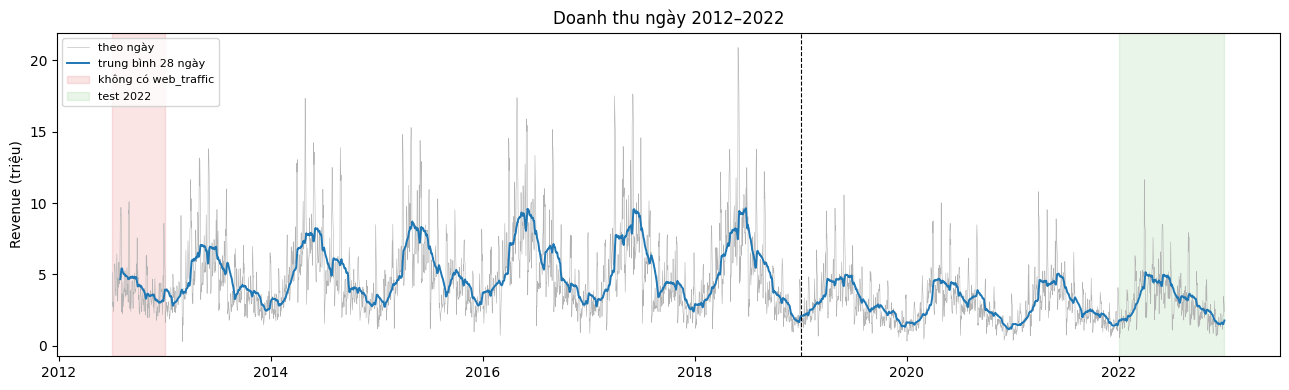

In [ ]:
yearly = s['Revenue'].groupby(s.index.year).mean().rename('TB_ngay').to_frame()
yearly['so_voi_nam_truoc_%'] = (yearly['TB_ngay'].pct_change() * 100).round(1)
display(yearly.round({'TB_ngay': 0}))

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(s.index, s['Revenue'] / 1e6, lw=0.4, color='0.7', label='theo ngày')
ax.plot(s.index, s['Revenue'].rolling(28).mean() / 1e6, lw=1.4, color='C0', label='trung bình 28 ngày')
ax.axvspan(pd.Timestamp('2012-07-04'), pd.Timestamp('2012-12-31'), color='C3', alpha=0.12, label='không có web_traffic')
ax.axvspan(pd.Timestamp('2022-01-01'), s.index.max(), color='C2', alpha=0.10, label='test 2022')
ax.axvline(pd.Timestamp('2019-01-01'), color='k', ls='--', lw=0.8)
ax.set_ylabel('Revenue (triệu)')
ax.set_title('Doanh thu ngày 2012–2022')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

**Nhận xét**

- `sales` chạy từ 04/07/2012 (thứ 4) đến 31/12/2022 (thứ 7): **3.833 ngày, không thiếu ngày nào**. Năm 2022 đủ 12 tháng, nên dùng làm test được.
- Gom theo tuần thứ 2–chủ nhật được 548 tuần. Bỏ tuần đầu (5 ngày) và tuần cuối 26–31/12/2022 (6 ngày, thiếu chủ nhật) thì còn **546 tuần đủ ngày**, tức khoảng 546 × 4 = 2.184 mẫu cho PA1.
- Với horizon 4 tuần và mốc cắt vào mỗi chủ nhật:
  - 2022 (test) có **49 mốc cắt**, từ 26/12/2021 đến 27/11/2022;
  - 2021 (validation) cũng có 49 mốc.
- Tuần gán theo ngày chủ nhật kết thúc tuần. Ví dụ tuần 27/12/2021–02/01/2022 thuộc năm 2022.
- Doanh thu trung bình ngày giảm 38,6% vào năm 2019 (từ khoảng 5,07 xuống 3,11 triệu) và đến 2022 vẫn chưa hồi phục.
- Dữ liệu không có năm 2023. Giai đoạn 2023–2024 trong `sample_submission` là phần cuộc thi tự chấm.

## 5. Bảng inventory (ô Chất lượng, bảng 1.1)

Xem tần suất snapshot, cách tính các cột hết hàng, con số 67,3% và khả năng rò rỉ dữ liệu khi dùng inventory làm đặc trưng.

In [ ]:
per_period = inv.groupby('snapshot_date').size()
print('Snapshot rơi vào ngày cuối tháng:', inv['snapshot_date'].eq(inv['snapshot_date'] + pd.offsets.MonthEnd(0)).mean())
print(f"Số kỳ: {inv['snapshot_date'].nunique()} ({inv['snapshot_date'].min().date()} → {inv['snapshot_date'].max().date()}),"
      f" mỗi kỳ {per_period.min()}–{per_period.max()} SKU")
print('Số kỳ mỗi SKU:', inv.groupby('product_id').size().describe()[['min', '50%', 'max']].to_dict())
print()
print('stockout_flag = 1:', round(inv['stockout_flag'].mean() * 100, 2), '%',
      '| trùng với stockout_days > 0:', (inv['stockout_flag'] == inv['stockout_days'].gt(0)).all())
print('overstock_flag = 1:', round(inv['overstock_flag'].mean() * 100, 2), '%',
      '| trùng với days_of_supply > 90:', (inv['overstock_flag'] == inv['days_of_supply'].gt(90)).all())
print('reorder_flag nhận các giá trị:', inv['reorder_flag'].unique())
approx = 1 - inv['stockout_days'] / inv['snapshot_date'].dt.days_in_month
print('corr(fill_rate, 1 - stockout_days/số ngày trong tháng):', round(np.corrcoef(inv['fill_rate'], approx)[0, 1], 4))
prev = inv_sorted.groupby('product_id')['stock_on_hand'].shift()
flow = (prev + inv_sorted['units_received'] - inv_sorted['units_sold'] == inv_sorted['stock_on_hand'])[prev.notna()]
print('Tồn cuối = tồn đầu + nhập - bán:', flow.mean())
print('\nstockout_days:', inv['stockout_days'].value_counts().sort_index().head(6).to_dict())

Snapshot rơi vào ngày cuối tháng: 1.0
Số kỳ: 126 (2012-07-31 → 2022-12-31), mỗi kỳ 376–562 SKU
Số kỳ mỗi SKU: {'min': 1.0, '50%': 27.0, 'max': 126.0}

stockout_flag = 1: 67.34 % | trùng với stockout_days > 0: True
overstock_flag = 1: 76.26 % | trùng với days_of_supply > 90: True
reorder_flag nhận các giá trị: [0]
corr(fill_rate, 1 - stockout_days/số ngày trong tháng): 0.9995
Tồn cuối = tồn đầu + nhập - bán: 1.0

stockout_days: {0: 19676, 1: 19654, 2: 19658, 3: 237, 4: 174, 5: 124}


corr với lượng bán cùng tháng: 0.990 | tháng trước: 0.830
units_sold / lượng bán cùng tháng (trung vị): 0.286


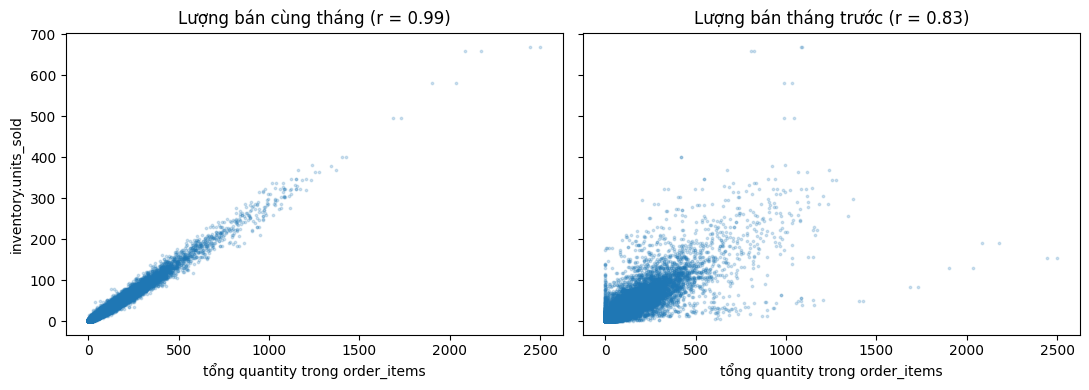

In [ ]:
# units_sold của snapshot tháng M khớp với lượng bán tháng M hay tháng M-1?
q_prev = q_month.rename('qty_prev_month').reset_index()
q_prev['snapshot_date'] += pd.offsets.MonthEnd(1)
lk = inv_q.join(q_prev.set_index(['product_id', 'snapshot_date'])['qty_prev_month'],
                on=['product_id', 'snapshot_date']).fillna({'qty_prev_month': 0})
r_same = lk['units_sold'].corr(lk['qty_month'])
r_prev = lk['units_sold'].corr(lk['qty_prev_month'])
print(f'corr với lượng bán cùng tháng: {r_same:.3f} | tháng trước: {r_prev:.3f}')
print('units_sold / lượng bán cùng tháng (trung vị):', round((lk['units_sold'] / lk['qty_month'].replace(0, np.nan)).median(), 3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, col, r, name in [(axes[0], 'qty_month', r_same, 'cùng tháng'), (axes[1], 'qty_prev_month', r_prev, 'tháng trước')]:
    ax.scatter(lk[col], lk['units_sold'], s=3, alpha=0.2)
    ax.set_title(f'Lượng bán {name} (r = {r:.2f})')
    ax.set_xlabel('tổng quantity trong order_items')
axes[0].set_ylabel('inventory.units_sold')
plt.tight_layout(); plt.show()

In [ ]:
# doanh thu mất do hết hàng: so hai cách quy đổi
oi_m['rev'] = oi_m['quantity'] * oi_m['unit_price']
rev_month = oi_m.groupby(['product_id', 'snapshot_date'])['rev'].sum().rename('rev_month')
x = inv.join(rev_month, on=['product_id', 'snapshot_date']).fillna({'rev_month': 0})
x = x.join(oi.groupby('product_id')['unit_price'].mean().rename('avg_price'), on='product_id')
lost_units = x['units_sold'] / x['fill_rate'] - x['units_sold']
print(f"units_sold x giá trung bình: {(lost_units * x['avg_price']).sum() / 1e6:,.1f} triệu")
print(f"doanh thu order_items x (1/fill_rate - 1): {(x['rev_month'] * (1 / x['fill_rate'] - 1)).sum() / 1e6:,.1f} triệu")

units_sold x giá trung bình: 428.5 triệu
doanh thu order_items x (1/fill_rate - 1): 1,448.8 triệu


**Nhận xét**

- Snapshot được chụp **mỗi tháng một lần, vào ngày cuối tháng**: 126 kỳ từ 07/2012 đến 12/2022, mỗi kỳ có 376–562 SKU. Ở bảng 1.1, mỗi dòng là "1 SKU tại 1 kỳ cuối tháng".
- **67,3%** là tỷ lệ snapshot có `stockout_flag = 1`, tức là trong tháng đó SKU hết hàng ít nhất 1 ngày. Tỷ lệ cao nhưng mỗi lần hết hàng chỉ ngắn: `stockout_days` gần như chỉ nhận ba giá trị 0, 1, 2 với tỷ lệ ngang nhau, và `fill_rate` trung bình là 0,96.
- Cách các cột được tính:
  - `stockout_flag` = `stockout_days > 0`;
  - `overstock_flag` = `days_of_supply > 90`;
  - `fill_rate` ≈ 1 − `stockout_days` / số ngày trong tháng;
  - tồn cuối = tồn đầu + nhập − bán, đúng ở mọi dòng.
- Các cột thừa:
  - `reorder_flag` luôn bằng 0, nên bỏ;
  - `product_name`, `category`, `segment`, `year`, `month` chỉ lặp lại thông tin đã có ở `products` và `snapshot_date`.
- **Rò rỉ dữ liệu.** `units_sold` của snapshot tháng M khớp với lượng bán của chính tháng M (r = 0,99; với tháng trước chỉ r = 0,83). Nghĩa là snapshot cuối tháng tổng hợp lại cả tháng vừa qua.
  - Khi làm đặc trưng, tại mốc cắt t chỉ lấy snapshot có `snapshot_date <= t` (dùng `pd.merge_asof(..., direction='backward')`).
  - Không join theo (năm, tháng) của tuần cần dự báo.
- **`units_sold` không cùng thang đo với `order_items`.** Nó chỉ bằng khoảng 0,29 lần số lượng bán thật. Vì vậy, nếu ước tính doanh thu mất do hết hàng bằng `units_sold × giá` thì chỉ ra khoảng 429 triệu, còn tính từ doanh thu `order_items` thì ra khoảng 1.449 triệu, gấp khoảng 3,4 lần.

## 6. SKU giá dưới 100 (ô Chất lượng, mục 1.3)

SKU giá < 100: 654 (27.1%)


,n,gia_min,gia_tv,gia_max,cogs_ratio_min,cogs_ratio_max,co_ban,co_ton_kho
low_price,,,,,,,,
False,1758,113.47,5606.06,40950.0,0.50,0.95,1598,1624
True,654,9.06,33.22,98.3,0.55,0.65,0,0


Trung vị giá: tất cả SKU = 4400 | SKU có bán = 5505
Tên có cả hai loại giá: 63 | giá cao / giá thấp: 67 → 960 lần


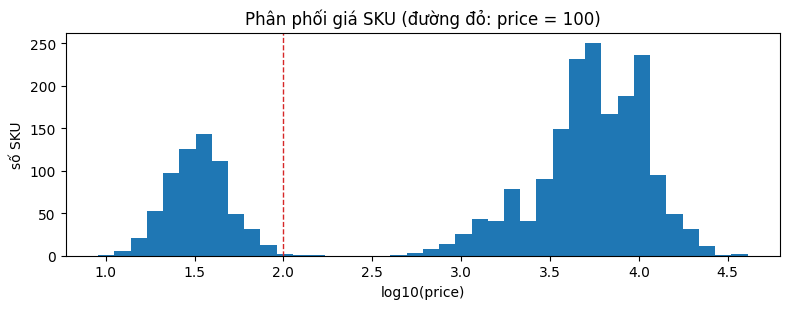

In [ ]:
prod['low_price'] = prod['price'] < 100
prod['sold'] = prod['product_id'].isin(oi['product_id'])
prod['in_inventory'] = prod['product_id'].isin(inv['product_id'])
prod['cogs_ratio'] = prod['cogs'] / prod['price']

print(f"SKU giá < 100: {prod['low_price'].sum()} ({prod['low_price'].mean() * 100:.1f}%)")
display(prod.groupby('low_price').agg(n=('price', 'size'), gia_min=('price', 'min'), gia_tv=('price', 'median'),
                                      gia_max=('price', 'max'), cogs_ratio_min=('cogs_ratio', 'min'),
                                      cogs_ratio_max=('cogs_ratio', 'max'), co_ban=('sold', 'sum'),
                                      co_ton_kho=('in_inventory', 'sum')).round(2))
print('Trung vị giá: tất cả SKU =', round(prod['price'].median()), '| SKU có bán =', round(prod.loc[prod['sold'], 'price'].median()))

# cùng product_name, một SKU giá thấp và một SKU giá thường: tỷ lệ giá có cố định không?
pairs = prod.groupby('product_name').filter(lambda d: d['low_price'].any() and (~d['low_price']).any())
ratio = pairs.groupby('product_name')['price'].agg(lambda x: x.max() / x.min())
print(f'Tên có cả hai loại giá: {ratio.size} | giá cao / giá thấp: {ratio.min():.0f} → {ratio.max():.0f} lần')

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.hist(np.log10(prod['price']), bins=40)
ax.axvline(2, color='C3', ls='--', lw=1)
ax.set_xlabel('log10(price)'); ax.set_ylabel('số SKU'); ax.set_title('Phân phối giá SKU (đường đỏ: price = 100)')
plt.tight_layout(); plt.show()

**Nhận xét**

- 654 SKU (27,1%) có giá 9–98. Phân phối `log10(price)` tách thành hai cụm rõ rệt.
- Nhóm này **không phải lỗi đơn vị**:
  - Nếu là lỗi đơn vị, SKU cùng tên sẽ lệch giá theo một hệ số cố định (như 100 hay 1.000). Thực tế hệ số dao động từ 67 đến 960 lần.
  - `cogs/price` của nhóm này nằm gọn trong khoảng 0,55–0,65, còn nhóm thường trải từ 0,50 đến 0,95.
  - Cả 654 SKU **chưa từng được bán** và **không có trong inventory**.
- Đây là SKU không hoạt động, **không ảnh hưởng đến nhãn PA1**.
- Số SKU thực sự hoạt động là 1.598 (có bán). Trung vị giá của nhóm này là khoảng 5.505, không phải 4.400.

## 7. Đơn vị tiền tệ (ô Chất lượng, mục 1.3)

In [ ]:
print('Giá trị đơn: TB', round(order_total.mean()), '| trung vị', round(order_total.median()))
print('unit_price: trung vị', round(oi['unit_price'].median()), '| min', round(oi['unit_price'].min()), '| max', round(oi['unit_price'].max()))
print('shipping_fee: trung vị', dfs['shipments']['shipping_fee'].median(), '| max', dfs['shipments']['shipping_fee'].max())
print('Revenue ngày: trung vị', round(s['Revenue'].median()))
print('min_order_value của khuyến mãi:', sorted(dfs['promotions']['min_order_value'].unique().tolist()))

Giá trị đơn: TB 24238 | trung vị 17229
unit_price: trung vị 4258 | min 393 | max 43056
shipping_fee: trung vị 1.73 | max 32.0
Revenue ngày: trung vị 3647304
min_order_value của khuyến mãi: [0, 50000, 100000, 150000, 200000]


**Nhận xét**

- Dữ liệu không có cột nào ghi đơn vị tiền, và chưa có thông tin chính thức từ BTC. Vì vậy notebook giữ số theo đơn vị gốc; biểu đồ chỉ ghi "triệu", không ghi VNĐ.
- Các con số khớp nhau về mặt nội bộ: giá trị đơn trung bình khoảng 24.000, `payment_value` bằng đúng tổng tiền hàng.
- `shipping_fee` (trung vị 1,73) lệch thang đo so với giá hàng, và không được cộng vào `payment_value`.
- WMAPE không phụ thuộc đơn vị, nên việc này không ảnh hưởng đến đánh giá mô hình.

## 8. Tóm tắt

**Ô Chất lượng**

> Không có dòng trùng; 16 dòng `order_items` trùng (order_id, product_id) là hai dòng hàng riêng, giữ nguyên. Ô rỗng chỉ ở 3 cột mang nghĩa "không áp dụng" (promo_id 61,3%, promo_id_2 99,97%, applicable_category 80%). Thiếu thật: traffic thiếu 181 ngày nửa cuối 2012 (04/07–31/12); 564 đơn đã gửi (0,1%) không có vận đơn; inventory chỉ có 1.624/2.412 SKU. Mâu thuẫn: 73,8% đơn đặt trước ngày tạo tài khoản; 18,6% dòng hàng (133.052) bán dưới giá vốn; 50,6% snapshot vừa hết hàng vừa tồn dư. 654 SKU (27,1%) giá < 100 không phải lỗi đơn vị mà là SKU không hoạt động (chưa từng bán, không có tồn kho), không ảnh hưởng nhãn. Đơn vị tiền tệ: chưa có thông tin chính thức.

**Ô Thời gian**

> Theo ngày, 04/07/2012 – 31/12/2022, 3.833 ngày, không thiếu ngày; năm 2022 đủ 12 tháng. Theo tuần T2–CN: 546 tuần đủ ngày (bỏ tuần đầu 5 ngày và tuần cuối 6 ngày). Doanh thu trung bình ngày giảm khoảng 39% từ 2019 và chưa hồi phục.

**Số liệu trong bản đề xuất cần cập nhật**

- Bảng 1.1:
  - inventory: "1 SKU tại 1 kỳ snapshot cuối tháng (126 kỳ, 07/2012–12/2022)";
  - order_items: "1 dòng hàng trong 1 đơn".
- Bảng 1.2, ô Quy mô: sales có 3.833 ngày; promotions 50 dòng; shipments 566.067 dòng.
- Bảng 1.2, ô Chất lượng: "181 ngày đầu 2012" sửa thành "181 ngày nửa cuối 2012".
- Mục 1.3: trung vị giá của SKU có bán là khoảng 5.505.
- Bảng 4.1, PA1, ô (2): khoảng 546 tuần × 4 danh mục ≈ 2.184 mẫu.

**Lưu ý khi làm đặc trưng và chia tập**

- Validation 2021 và test 2022 mỗi năm có 49 mốc cắt. Bỏ tuần lẻ cuối cùng. Tuần gán theo ngày chủ nhật kết thúc tuần.
- Inventory join theo `snapshot_date <= mốc cắt` (merge_asof). Bỏ `reorder_flag`.
- `inventory.units_sold` chỉ bằng khoảng 0,29 lần số lượng trong `order_items`. Khi ước tính doanh thu mất do hết hàng, lấy doanh thu từ `order_items` nhân với (1/`fill_rate` − 1). Theo cách này, doanh thu mất khoảng 1.449 triệu (xem mục 5).

# Phần C. Nhãn, chi phí của việc làm sai và kiểm chứng nhanh PA3

Phụ trách: Minh Huy

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
import time
import warnings
warnings.filterwarnings('ignore')

# Cấu hình matplotlib
plt.rcParams['figure.figsize'] = (14, 6)

# DATA_DIR lấy từ Phần 0

## 1. Kiểm tra Nhãn: Độ lệch `sales` và `order_items` với Chiết khấu (Discounts)

In [ ]:
order_items = pd.read_csv(f"{DATA_DIR}/order_items.csv", low_memory=False)
orders = pd.read_csv(f"{DATA_DIR}/orders.csv")
sales = pd.read_csv(f"{DATA_DIR}/sales.csv")

# Gộp order_items và orders để lấy ngày
merged = pd.merge(order_items, orders[['order_id', 'order_date']], on='order_id')
merged['gross_revenue'] = merged['quantity'] * merged['unit_price']
merged['net_revenue'] = merged['gross_revenue'] - merged['discount_amount'].fillna(0)

# Tổng hợp theo ngày
daily_orders = merged.groupby('order_date').agg(
    gross_revenue=('gross_revenue', 'sum'),
    net_revenue=('net_revenue', 'sum'),
    discount=('discount_amount', 'sum')
).reset_index()

daily_orders['order_date'] = pd.to_datetime(daily_orders['order_date'])
sales['Date'] = pd.to_datetime(sales['Date'])
merged_sales = pd.merge(sales, daily_orders, left_on='Date', right_on='order_date', how='inner')

# So sánh
print("Does sales.Revenue == order_items.gross_revenue?", np.allclose(merged_sales['Revenue'], merged_sales['gross_revenue']))

discount_pct_gross = merged_sales['discount'] / merged_sales['gross_revenue']
print("\nTrung bình phần trăm chiết khấu trên doanh thu gộp (discount/gross):", round(discount_pct_gross.mean() * 100, 2), "%")
print("Các cụm phần trăm chiết khấu phổ biến:")
print((discount_pct_gross * 100).round(1).value_counts().head(10))

Does sales.Revenue == order_items.gross_revenue? True

Trung bình phần trăm chiết khấu trên doanh thu gộp (discount/gross): 5.17 %
Các cụm phần trăm chiết khấu phổ biến:
0.0     2127
20.0     384
10.0     264
12.0     231
18.0     220
0.9       56
0.8       49
1.0       33
0.7       16
2.0       12
Name: count, dtype: int64


## Biểu đồ doanh thu và giá vốn theo ngày
Yêu cầu: Nhãn biểu đồ dùng 'Triệu' thay vì 'Tỷ VNĐ'.

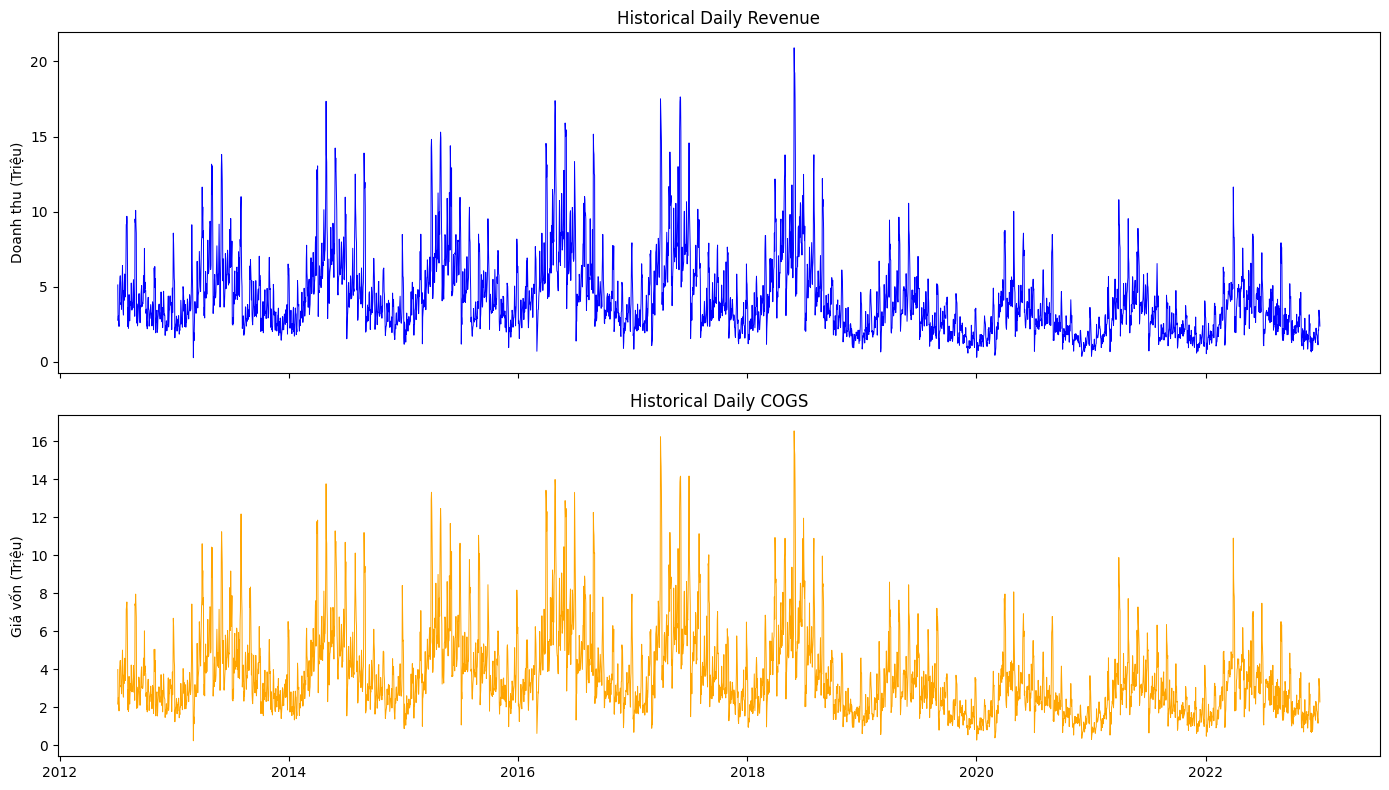

In [ ]:
# Biểu đồ Doanh thu (quy ra Triệu VNĐ)
sales['Revenue_Million'] = sales['Revenue'] / 1e6
sales['COGS_Million'] = sales['COGS'] / 1e6

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(sales['Date'], sales['Revenue_Million'], lw=0.7, color='blue')
axes[0].set_title('Historical Daily Revenue')
axes[0].set_ylabel('Doanh thu (Triệu)')

axes[1].plot(sales['Date'], sales['COGS_Million'], lw=0.7, color='orange')
axes[1].set_title('Historical Daily COGS')
axes[1].set_ylabel('Giá vốn (Triệu)')

plt.tight_layout()
plt.show()

## 2. Chi phí của việc làm sai (mục 2.1)

**Giả định:** Coi toàn bộ lỗ của các ngày có lãi gộp âm là do nhập thừa hàng và phải xả lỗ.
Doanh thu mất được ước theo từng SKU × tháng: doanh thu thực tế × (1/fill_rate − 1).

In [ ]:
import numpy as np
import pandas as pd

DATA = DATA_DIR + '/'  # từ Phần 0
order_items = pd.read_csv(f"{DATA}order_items.csv", low_memory=False)
orders = pd.read_csv(f"{DATA}orders.csv", parse_dates=["order_date"])
sales = pd.read_csv(f"{DATA}sales.csv", parse_dates=["Date"])
inventory = pd.read_csv(f"{DATA}inventory.csv", parse_dates=["snapshot_date"])

print("Các trạng thái đơn:", orders["order_status"].unique())
orders_ok = orders[orders["order_status"].str.lower() != "cancelled"]

# Doanh thu ròng từng dòng hàng, bỏ đơn hủy (dùng lại ở cell 15)
items = order_items.merge(orders_ok[["order_id", "order_date"]], on="order_id")
items["net_revenue"] = items["quantity"] * items["unit_price"] - items["discount_amount"].fillna(0)
items["month"] = items["order_date"].dt.to_period("M")

# (1) Doanh thu mất: ghép theo SKU × tháng
rev_pm = items.groupby(["product_id", "month"])[["net_revenue"]].sum().reset_index()
inv = inventory[["product_id", "snapshot_date", "fill_rate"]].copy()
if inv["fill_rate"].max() > 1:          # phòng trường hợp lưu theo %
    inv["fill_rate" ] = inv["fill_rate"] / 100
inv["month"] = inv["snapshot_date"].dt.to_period("M")
inv = inv.merge(rev_pm, on=["product_id", "month"], how="inner")
inv = inv[inv["fill_rate"] > 0]
inv["lost_revenue"] = inv["net_revenue"] * (1 / inv["fill_rate"] - 1)
lost_revenue = inv["lost_revenue"].sum()

# (2) Biên lãi gộp ngày bình thường (bỏ các ngày lỗ)
s = sales.copy()
s["gp"] = s["Revenue"] - s["COGS"]
s["gp_pct"] = s["gp"] / s["Revenue"]
normal_margin = s.loc[s["gp"] >= 0, "gp_pct"].median()

# (3) Lãi mất do hết hàng, (4) lỗ xả hàng
profit_lost = lost_revenue * normal_margin
loss_days = s[s["gp"] < 0]
clearance_loss = -loss_days["gp"].sum()

print("=== CHI PHÍ CỦA VIỆC LÀM SAI ===")
print(f"Số snapshot ghép được doanh thu: {len(inv):,}")
print(f"1. Doanh thu mất do hết hàng:      {lost_revenue/1e6:,.1f} triệu")
print(f"2. Biên lãi gộp ngày bình thường:  {normal_margin*100:.1f}%")
print(f"3. Lãi mất do hết hàng (dự báo thấp): {profit_lost/1e6:,.1f} triệu")
print(f"4. Lỗ xả hàng {len(loss_days)} ngày (dự báo cao): {clearance_loss/1e6:,.1f} triệu")
worse = "Dự báo THẤP (hết hàng)" if profit_lost > clearance_loss else "Dự báo CAO (xả lỗ)"
print(f"\n=> KẾT LUẬN: {worse} tốn kém hơn.")

Các trạng thái đơn: ['delivered' 'returned' 'shipped' 'cancelled' 'paid' 'created']
=== CHI PHÍ CỦA VIỆC LÀM SAI ===
Số snapshot ghép được doanh thu: 55,546
1. Doanh thu mất do hết hàng:      1,255.6 triệu
2. Biên lãi gộp ngày bình thường:  18.5%
3. Lãi mất do hết hàng (dự báo thấp): 232.0 triệu
4. Lỗ xả hàng 382 ngày (dự báo cao): 192.2 triệu

=> KẾT LUẬN: Dự báo THẤP (hết hàng) tốn kém hơn.


## 3. Kiểm chứng nhanh PA3: baseline dự báo cuốn chiếu (bảng 4.1)

In [ ]:
import time
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Chuỗi doanh thu ngày theo định nghĩa PA1 (bỏ đơn hủy, trừ chiết khấu)
daily = items.groupby("order_date")["net_revenue"].sum().asfreq("D", fill_value=0)
val = daily.loc["2021-01-01":"2021-12-31"]

def wmape(y, p): return np.abs(y - p).sum() / y.sum()
def mae(y, p):   return np.abs(y - p).mean()

# A. Seasonal-naive: lấy cùng thứ, cách 364 ngày
t0 = time.time()
pred_sn = daily.shift(364).loc[val.index]
t_sn = time.time() - t0

# B. SARIMA dự báo từng đợt 28 ngày, train từ 2019 (sau điểm gãy), trên log doanh thu
t0 = time.time()
y_log = np.log1p(daily.loc["2019-01-01":])
preds, cutoff = [], pd.Timestamp("2020-12-31")
while cutoff < val.index[-1]:
    res = SARIMAX(y_log.loc[:cutoff], order=(1, 1, 1),
                  seasonal_order=(0, 1, 1, 7)).fit(disp=False)
    preds.append(np.expm1(res.forecast(steps=28)))
    cutoff += pd.Timedelta(days=28)
pred_sa = pd.concat(preds).reindex(val.index)
t_sa = time.time() - t0

summary = pd.DataFrame({
    "Mô hình": ["Seasonal-naive (364 ngày)", "SARIMA(1,1,1)(0,1,1,7), 28 ngày/lần"],
    "WMAPE (%)": [round(wmape(val, pred_sn) * 100, 2), round(wmape(val, pred_sa) * 100, 2)],
    "MAE (triệu)": [round(mae(val, pred_sn) / 1e6, 3), round(mae(val, pred_sa) / 1e6, 3)],
    "Thời gian (giây)": [round(t_sn, 2), round(t_sa, 2)],
})
display(summary)
beat = wmape(val, pred_sa) < wmape(val, pred_sn)
print(f"Chuỗi doanh thu ròng theo ngày: {len(daily)} ngày, trung bình {daily.mean()/1e6:.2f} triệu, skewness {daily.skew():.2f}")
print("=> KẾT LUẬN: SARIMA", "VƯỢT" if beat else "KHÔNG vượt", "seasonal-naive trên validation 2021.")

,Mô hình,WMAPE (%),MAE (triệu),Thời gian (giây)
0,Seasonal-naive (364 ngày),27.82,0.686,0.00
1,"SARIMA(1,1,1)(0,1,1,7), 28 ngày/lần",34.31,0.846,39.78


=> KẾT LUẬN: SARIMA KHÔNG vượt seasonal-naive trên validation 2021.


# Phần D. Tên cột thật, quy tắc đơn hủy/trả và kiểm chứng nhanh PA1

Phụ trách: Văn Quyền. Phần này để cuối vì chuyển matplotlib sang backend Agg và hiển thị biểu đồ qua file ảnh.

## 0. Nhập thư viện và cấu hình

In [ ]:
import json, time, hashlib, os, sys
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import Image, display

ROOT = PROJECT_DIR  # từ Phần 0
DS = os.path.join(DATA_DIR, "")
OUT_DIR = os.path.join(ROOT, "outputs", "pa1")
OUT = os.path.join(OUT_DIR, "pa1_validation_evidence.json")
os.makedirs(OUT_DIR, exist_ok=True)

T0 = time.perf_counter()
ev = {}


def sha(p, n=1 << 20):
    h = hashlib.sha256()
    with open(p, "rb") as f:
        for b in iter(lambda: f.read(n), b""):
            h.update(b)
    return h.hexdigest()[:16]


BANG = ["order_items", "orders", "products", "promotions", "sales", "web_traffic", "inventory", "returns"]
ev["thong_tin_chung"] = {
    "nguoi_thuc_hien": "Nguyễn Văn Quyền",
    "pham_vi": "Phần 3 (phát biểu bài toán) + Phần 4.1 kiểm chứng nhanh PA1",
    "thoi_diem_chay": pd.Timestamp.now().isoformat(timespec="seconds"),
    "python": sys.version.split()[0],
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "file_da_dung": {t: {"sha256_16": sha(os.path.join(DS, t + ".csv")),
                         "dung_luong_byte": os.path.getsize(os.path.join(DS, t + ".csv"))} for t in BANG},
}

## 1. Tên cột thật

In [ ]:
oi = pd.read_csv(os.path.join(DS, "order_items.csv"))
orders = pd.read_csv(os.path.join(DS, "orders.csv"), parse_dates=["order_date"])
prod = pd.read_csv(os.path.join(DS, "products.csv"))
promo = pd.read_csv(os.path.join(DS, "promotions.csv"), parse_dates=["start_date", "end_date"])
traffic = pd.read_csv(os.path.join(DS, "web_traffic.csv"), parse_dates=["date"])
inv = pd.read_csv(os.path.join(DS, "inventory.csv"), parse_dates=["snapshot_date"])
rets = pd.read_csv(os.path.join(DS, "returns.csv"), parse_dates=["return_date"])

ev["viec_1_ten_cot_that"] = {
    "ghi_chu": "Thay tên cột giả định trong bản đề xuất bằng tên cột thật trong file CSV.",
    "cau_truc_thuc_te": {t: list(df.columns) for t, df in
                         [("order_items", oi), ("orders", orders), ("products", prod),
                          ("promotions", promo), ("web_traffic", traffic), ("inventory", inv),
                          ("returns", rets)]},
    "sua_ten_cot": [
        {"trong_de_xuat": "discount", "ten_that": "order_items.discount_amount"},
        {"trong_de_xuat": "unit_price", "ten_that": "order_items.unit_price", "trang_thai": "đúng, giữ nguyên"},
        {"trong_de_xuat": "quantity", "ten_that": "order_items.quantity", "trang_thai": "đúng, giữ nguyên"},
        {"trong_de_xuat": "order_date",
         "ten_that": "orders.order_date (KHÔNG nằm trong order_items, phải nối qua order_id)"},
        {"trong_de_xuat": "category", "ten_that": "products.category (nối qua product_id)"},
        {"trong_de_xuat": "traffic",
         "ten_that": "web_traffic.date + sessions / unique_visitors / page_views / bounce_rate"},
        {"trong_de_xuat": "tồn kho snapshot",
         "ten_that": "inventory.snapshot_date + stock_on_hand / fill_rate / days_of_supply / stockout_flag"},
        {"trong_de_xuat": "phí ship",
         "ten_that": "shipments.shipping_fee - KHÔNG có trong order_items nên biến mục tiêu vốn đã không gồm phí ship"},
    ],
    "cong_thuc_bien_muc_tieu": (
        "revenue_net(danh_mục, tuần) = TỔNG(order_items.quantity * order_items.unit_price "
        "- order_items.discount_amount) trên các dòng có orders.order_date thuộc tuần đó "
        "và products.category = danh_mục, loại bỏ orders.order_status == 'cancelled'."
    ),
}

/tmp/ipykernel_1074/1205493290.py:1: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  oi = pd.read_csv(os.path.join(DS, "order_items.csv"))


## 1b. quy tắc đơn hủy / trả

In [ ]:
st = orders["order_status"].value_counts()
oi_line = oi.copy()
oi_line["doanh_thu_dong"] = oi_line["quantity"] * oi_line["unit_price"] - oi_line["discount_amount"]
m = oi_line.merge(orders[["order_id", "order_date", "order_status"]], on="order_id", how="inner")
m = m.merge(prod[["product_id", "category"]], on="product_id", how="inner")

rev_by_status = m.groupby("order_status")["doanh_thu_dong"].agg(["sum", "count"])
total_rev = float(m["doanh_thu_dong"].sum())
ret_orders = set(rets["order_id"])

ev["viec_1_quy_tac_don_huy_tra"] = {
    "cac_trang_thai_don_trong_du_lieu": {k: int(v) for k, v in st.items()},
    "doanh_thu_theo_trang_thai": {k: {"doanh_thu": float(r["sum"]), "so_dong": int(r["count"]),
                                      "ty_trong_phan_tram": round(float(r["sum"]) / total_rev * 100, 3)}
                                  for k, r in rev_by_status.iterrows()},
    "bang_returns": {
        "so_dong": int(len(rets)),
        "so_don_bi_tra": int(len(ret_orders)),
        "tong_tien_hoan": float(rets["refund_amount"].sum()),
        "khoang_ngay_tra": [str(rets["return_date"].min().date()), str(rets["return_date"].max().date())],
    },
    "quy_tac_chot": (
        "LOẠI đơn có order_status == 'cancelled' khỏi biến mục tiêu, vì đơn hủy không phát sinh "
        "doanh thu và không tiêu tốn hàng nhập. GIỮ đơn 'returned': tại mốc cắt đầu tuần, việc trả hàng "
        "chưa xảy ra nên không biết trước - loại trừ sẽ gây rò rỉ thông tin tương lai (look-ahead). "
        "GIỮ 'created'/'paid'/'shipped'/'delivered'. Cột refund_amount trong returns.csv chỉ dùng để "
        "báo cáo, KHÔNG trừ vào nhãn."
    ),
    "anh_huong_cua_quy_tac": {
        "doanh_thu_giu_tat_ca": total_rev,
        "doanh_thu_loai_cancelled": float(m.loc[m.order_status != "cancelled", "doanh_thu_dong"].sum()),
        "doanh_thu_loai_cancelled_va_returned": float(
            m.loc[~m.order_status.isin(["cancelled", "returned"]), "doanh_thu_dong"].sum()),
        "chenh_lech_phan_tram_khi_loai_cancelled": round(
            (float(m.loc[m.order_status != "cancelled", "doanh_thu_dong"].sum()) / total_rev - 1) * 100, 3),
    },
}

ev["viec_1_quy_tac_don_huy_tra"]

{'cac_trang_thai_don_trong_du_lieu': {'delivered': 516716,
  'cancelled': 59462,
  'returned': 36142,
  'shipped': 13773,
  'paid': 13577,
  'created': 7275},
 'doanh_thu_theo_trang_thai': {'cancelled': {'doanh_thu': 1447013637.43,
   'so_dong': 65673,
   'ty_trong_phan_tram': 9.228},
  'created': {'doanh_thu': 181835018.77,
   'so_dong': 7994,
   'ty_trong_phan_tram': 1.16},
  'delivered': {'doanh_thu': 12518175957.2,
   'so_dong': 570887,
   'ty_trong_phan_tram': 79.831},
  'paid': {'doanh_thu': 330627096.24,
   'so_dong': 14987,
   'ty_trong_phan_tram': 2.108},
  'returned': {'doanh_thu': 865938715.59,
   'so_dong': 40034,
   'ty_trong_phan_tram': 5.522},
  'shipped': {'doanh_thu': 337278840.2,
   'so_dong': 15094,
   'ty_trong_phan_tram': 2.151}},
 'bang_returns': {'so_dong': 39939,
  'so_don_bi_tra': 36062,
  'tong_tien_hoan': 510598506.55,
  'khoang_ngay_tra': ['2012-07-11', '2022-12-31']},
 'quy_tac_chot': "LOẠI đơn có order_status == 'cancelled' khỏi biến mục tiêu, vì đơn hủy k

## 2. bảng khuyến mãi lên lịch trước?

In [ ]:
promo_ok = promo.dropna(subset=["start_date", "end_date"])
lead = (promo_ok["end_date"] - promo_ok["start_date"]).dt.days
ev["viec_2_bang_khuyen_mai"] = {
    "ket_luan": "CÓ - promotions.csv là bảng khuyến mãi lên lịch trước, có start_date/end_date/discount_value.",
    "so_dong": int(len(promo)),
    "cac_cot": list(promo.columns),
    "khoang_thoi_gian": [str(promo_ok["start_date"].min().date()), str(promo_ok["end_date"].max().date())],
    "do_dai_chien_dich_ngay": {"nho_nhat": int(lead.min()), "trung_vi": float(lead.median()), "lon_nhat": int(lead.max())},
    "loai_khuyen_mai": {str(k): int(v) for k, v in promo["promo_type"].value_counts(dropna=False).items()},
    "danh_muc_ap_dung": {str(k): int(v) for k, v in promo["applicable_category"].value_counts(dropna=False).items()},
    "ty_le_thieu_danh_muc_ap_dung_phan_tram": round(float(promo["applicable_category"].isna().mean()) * 100, 2),
    "lien_ket_voi_order_items": {
        "cot_khoa": ["order_items.promo_id", "order_items.promo_id_2"],
        "ty_le_dong_co_promo_id_phan_tram": round(float(oi["promo_id"].notna().mean()) * 100, 2),
        "ty_le_dong_co_promo_id_2_phan_tram": round(float(oi["promo_id_2"].notna().mean()) * 100, 2),
        "so_promo_id_khop_bang_promotions": int(oi["promo_id"].dropna().isin(promo["promo_id"]).sum()),
    },
    "sua_o_muc_dau_vao": (
        "Đặc trưng chiết khấu KẾ HOẠCH là hợp lệ và biết trước: lấy từ promotions.csv "
        "(số chiến dịch đang chạy trong tuần t+h, tổng discount_value, có khuyến mãi theo danh mục) "
        "vì start_date/end_date đã biết từ trước mốc cắt. "
        "Riêng order_items.discount_amount là chiết khấu THỰC TẾ -> chỉ được dùng bản trễ (lag)."
    ),
}

ev["viec_2_bang_khuyen_mai"]

{'ket_luan': 'CÓ - promotions.csv là bảng khuyến mãi lên lịch trước, có start_date/end_date/discount_value.',
 'so_dong': 50,
 'cac_cot': ['promo_id',
  'promo_name',
  'promo_type',
  'discount_value',
  'start_date',
  'end_date',
  'applicable_category',
  'promo_channel',
  'stackable_flag',
  'min_order_value'],
 'khoang_thoi_gian': ['2013-01-31', '2022-12-31'],
 'do_dai_chien_dich_ngay': {'nho_nhat': 29, 'trung_vi': 30.5, 'lon_nhat': 45},
 'loai_khuyen_mai': {'percentage': 45, 'fixed': 5},
 'danh_muc_ap_dung': {'nan': 40, 'Streetwear': 5, 'Outdoor': 5},
 'ty_le_thieu_danh_muc_ap_dung_phan_tram': 80.0,
 'lien_ket_voi_order_items': {'cot_khoa': ['order_items.promo_id',
   'order_items.promo_id_2'],
  'ty_le_dong_co_promo_id_phan_tram': 38.66,
  'ty_le_dong_co_promo_id_2_phan_tram': 0.03,
  'so_promo_id_khop_bang_promotions': 276316},
 'sua_o_muc_dau_vao': 'Đặc trưng chiết khấu KẾ HOẠCH là hợp lệ và biết trước: lấy từ promotions.csv (số chiến dịch đang chạy trong tuần t+h, tổng disc

## 3. chuỗi tuần 4 danh mục

In [ ]:
panel = m.loc[m["order_status"] != "cancelled"].copy()
panel["tuan"] = panel["order_date"] - pd.to_timedelta(panel["order_date"].dt.weekday, unit="D")
wk = panel.groupby(["category", "tuan"])["doanh_thu_dong"].sum().rename("doanh_thu").reset_index()

danh_sach_tuan = pd.date_range(wk["tuan"].min(), wk["tuan"].max(), freq="W-MON")
danh_muc = sorted(prod["category"].unique())
grid = pd.MultiIndex.from_product([danh_muc, danh_sach_tuan], names=["category", "tuan"]).to_frame(index=False)
wk = grid.merge(wk, on=["category", "tuan"], how="left")
wk["doanh_thu"] = wk["doanh_thu"].fillna(0.0)

first_day, last_day = panel["order_date"].min(), panel["order_date"].max()
wk = wk[(wk["tuan"] >= first_day) & (wk["tuan"] + pd.Timedelta(days=6) <= last_day)]

pivot = wk.pivot(index="tuan", columns="category", values="doanh_thu").sort_index()

MOC_TRAIN, NAM_VAL, NAM_TEST = pd.Timestamp("2020-12-31"), 2021, 2022
idx = pivot.index
split = np.where(idx <= MOC_TRAIN, "train", np.where(idx.year == NAM_VAL, "validation", "test"))

ev["viec_3_chuoi_tuan"] = {
    "dinh_nghia_tuan": "Thứ 2 -> Chủ nhật, nhãn theo ngày Thứ 2; mốc cắt = cuối ngày Chủ nhật.",
    "khoang_tuan": [str(idx.min().date()), str(idx.max().date())],
    "so_tuan": int(len(idx)),
    "so_danh_muc": len(danh_muc),
    "danh_muc": danh_muc,
    "so_mau_tong": int(len(idx) * len(danh_muc)),
    "chia_du_lieu": {
        "quy_tac": "train <= 2020-12-31, validation = năm 2021, test = năm 2022 (chia theo thời gian, không xáo trộn)",
        "train": {"so_tuan": int((split == "train").sum()),
                  "tu_ngay": str(idx[split == "train"].min().date()), "den_ngay": str(idx[split == "train"].max().date()),
                  "so_mau": int((split == "train").sum() * len(danh_muc))},
        "validation": {"so_tuan": int((split == "validation").sum()),
                       "tu_ngay": str(idx[split == "validation"].min().date()),
                       "den_ngay": str(idx[split == "validation"].max().date()),
                       "so_mau": int((split == "validation").sum() * len(danh_muc))},
        "test": {"so_tuan": int((split == "test").sum()),
                 "tu_ngay": str(idx[split == "test"].min().date()), "den_ngay": str(idx[split == "test"].max().date()),
                 "so_mau": int((split == "test").sum() * len(danh_muc))},
    },
    "thong_ke_theo_danh_muc": {
        c: {
            "doanh_thu_tuan_trung_binh": float(pivot[c].mean()),
            "doanh_thu_tuan_trung_vi": float(pivot[c].median()),
            "do_lech_chuan": float(pivot[c].std()),
            "nho_nhat": float(pivot[c].min()), "lon_nhat": float(pivot[c].max()),
            "do_lech_skewness": float(pivot[c].skew()),
            "so_tuan_bang_0": int((pivot[c] == 0).sum()),
            "ty_le_tuan_bang_0_phan_tram": round(float((pivot[c] == 0).mean()) * 100, 3),
            "ty_trong_doanh_thu_phan_tram": round(float(pivot[c].sum() / pivot.values.sum()) * 100, 2),
        } for c in danh_muc},
}

ev["viec_3_chuoi_tuan"]

{'dinh_nghia_tuan': 'Thứ 2 -> Chủ nhật, nhãn theo ngày Thứ 2; mốc cắt = cuối ngày Chủ nhật.',
 'khoang_tuan': ['2012-07-09', '2022-12-19'],
 'so_tuan': 546,
 'so_danh_muc': 4,
 'danh_muc': ['Casual', 'GenZ', 'Outdoor', 'Streetwear'],
 'so_mau_tong': 2184,
 'chia_du_lieu': {'quy_tac': 'train <= 2020-12-31, validation = năm 2021, test = năm 2022 (chia theo thời gian, không xáo trộn)',
  'train': {'so_tuan': 443,
   'tu_ngay': '2012-07-09',
   'den_ngay': '2020-12-28',
   'so_mau': 1772},
  'validation': {'so_tuan': 52,
   'tu_ngay': '2021-01-04',
   'den_ngay': '2021-12-27',
   'so_mau': 208},
  'test': {'so_tuan': 51,
   'tu_ngay': '2022-01-03',
   'den_ngay': '2022-12-19',
   'so_mau': 204}},
 'thong_ke_theo_danh_muc': {'Casual': {'doanh_thu_tuan_trung_binh': 729593.5803663003,
   'doanh_thu_tuan_trung_vi': 623414.4650000001,
   'do_lech_chuan': 469714.81423761434,
   'nho_nhat': 51314.700000000004,
   'lon_nhat': 4425906.66,
   'do_lech_skewness': 1.9668535558393723,
   'so_tuan_bang_

## 4. baseline

In [ ]:
def wmape(y, yh):
    d = np.abs(y).sum()
    return float(np.abs(y - yh).sum() / d) if d > 0 else float("nan")


def chay_baseline(cac_nam_danh_gia):
    """Rolling origin: mỗi tuần t trong lịch sử làm mốc cắt -> dự báo t+1..t+4."""
    rows = []
    vals = pivot.values
    n = len(pivot)
    for ti in range(n):
        for h in range(1, 5):
            tgt = ti + h
            if tgt >= n or idx[tgt].year not in cac_nam_danh_gia:
                continue
            for ci, c in enumerate(danh_muc):
                y = vals[tgt, ci]
                sn = vals[tgt - 52, ci] if tgt - 52 >= 0 else np.nan          # seasonal-naive lag 52 tuần
                ma = vals[ti - 3:ti + 1, ci].mean() if ti - 3 >= 0 else np.nan  # trung bình 4 tuần trước mốc cắt
                rows.append((c, h, y, sn, ma))
    return pd.DataFrame(rows, columns=["category", "h", "y_that", "seasonal_naive", "trung_binh_4_tuan"]).dropna()


t_b0 = time.perf_counter()
bt = chay_baseline({NAM_VAL})
t_baseline = time.perf_counter() - t_b0


def cham_diem(df):
    return {
        "so_mau": int(len(df)),
        "seasonal_naive": {"WMAPE": round(wmape(df.y_that.values, df.seasonal_naive.values), 4),
                           "MAE": round(float(np.abs(df.y_that - df.seasonal_naive).mean()), 2)},
        "trung_binh_4_tuan": {"WMAPE": round(wmape(df.y_that.values, df.trung_binh_4_tuan.values), 4),
                              "MAE": round(float(np.abs(df.y_that - df.trung_binh_4_tuan).mean()), 2)},
    }


ev["viec_3_baseline_validation_2021"] = {
    "thiet_ke": "Rolling origin: mỗi tuần t trong lịch sử làm mốc cắt, dự báo h = 1..4 tuần; "
                "chỉ chấm điểm các tuần mục tiêu rơi vào năm 2021.",
    "do_do": "WMAPE = tổng|thật - dự báo| / tổng|thật| (chính), MAE (phụ).",
    "baseline_1_seasonal_naive": "dự báo(t+h) = doanh thu(t+h-52) - cùng kỳ năm trước.",
    "baseline_2_trung_binh_4_tuan": "dự báo(t+h) = trung bình 4 tuần gần nhất trước mốc cắt t.",
    "tong_the": cham_diem(bt),
    "theo_danh_muc": {c: cham_diem(g) for c, g in bt.groupby("category")},
    "theo_horizon": {"h%d" % h: cham_diem(g) for h, g in bt.groupby("h")},
    "thoi_gian_chay_baseline_giay": round(t_baseline, 3),
}

bt22 = chay_baseline({NAM_TEST})
ev["viec_3_baseline_test_2022_tham_khao"] = {
    "canh_bao": "Chỉ để tham khảo. Việc chọn mô hình phải dựa trên validation 2021.",
    "tong_the": cham_diem(bt22),
    "theo_danh_muc": {c: cham_diem(g) for c, g in bt22.groupby("category")},
}

ev["ket_luan_PA1"] = {
    "du_lieu": "ĐẠT - nhãn tạo được từ order_items + orders + products; số mẫu = %d (tuần x danh mục)."
               % (len(idx) * len(danh_muc)),
    "ky_thuat": "ĐẠT - baseline chạy %.2f giây, cả pipeline %.1f giây."
                % (t_baseline, time.perf_counter() - T0),
    "rui_ro": "Casual và GenZ tỷ trọng doanh thu nhỏ -> WMAPE cao hơn, xem mục theo_danh_muc.",
}
ev["thong_tin_chung"]["tong_thoi_gian_chay_giay"] = round(time.perf_counter() - T0, 2)

with open(OUT, "w", encoding="utf-8") as f:
    json.dump(ev, f, ensure_ascii=False, indent=2)
ev["ket_luan_PA1"]

{'du_lieu': 'ĐẠT - nhãn tạo được từ order_items + orders + products; số mẫu = 2184 (tuần x danh mục).',
 'ky_thuat': 'ĐẠT - baseline chạy 0.02 giây, cả pipeline 89.9 giây.',
 'rui_ro': 'Casual và GenZ tỷ trọng doanh thu nhỏ -> WMAPE cao hơn, xem mục theo_danh_muc.'}

## 5. Biểu đồ minh họa

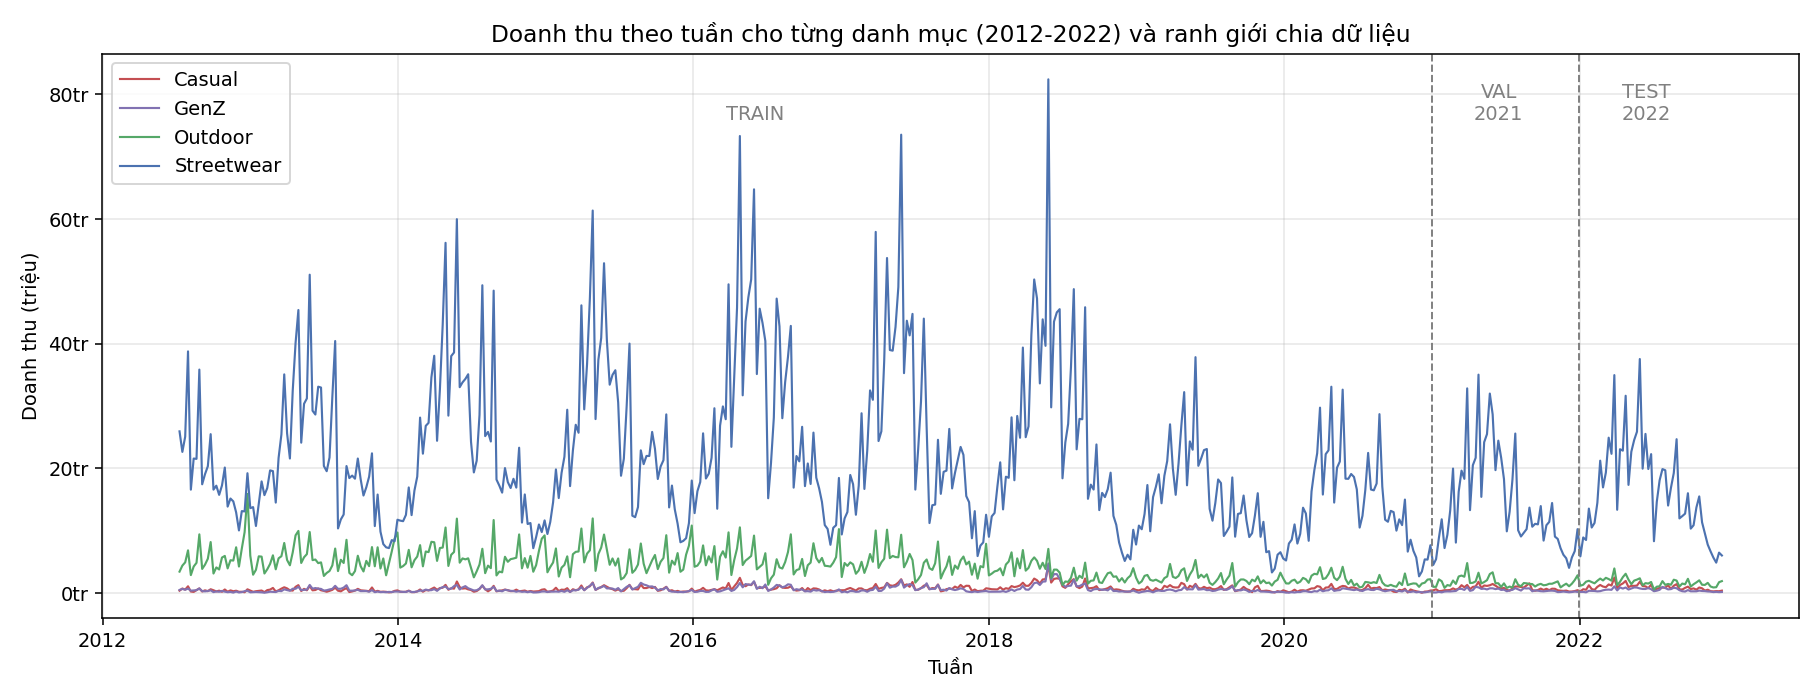

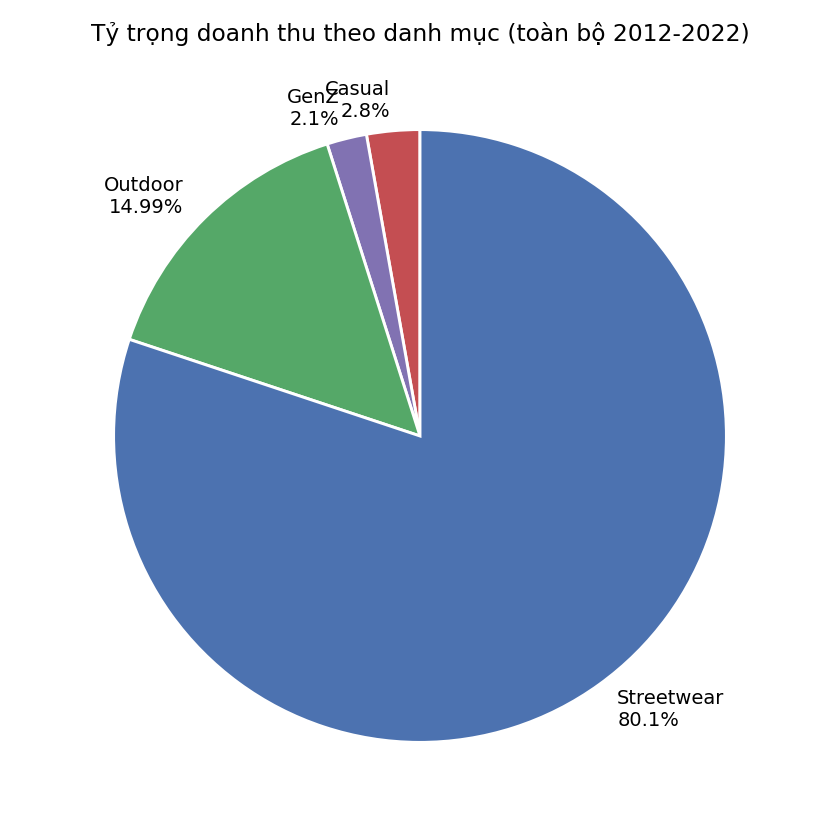

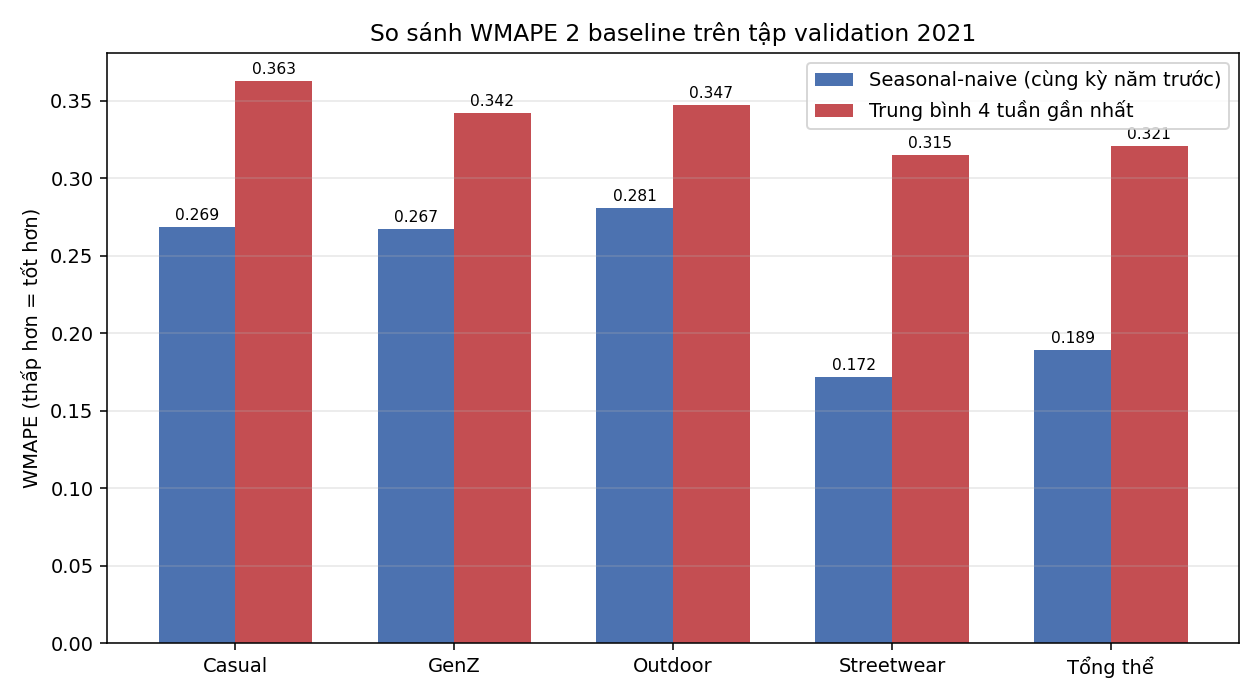

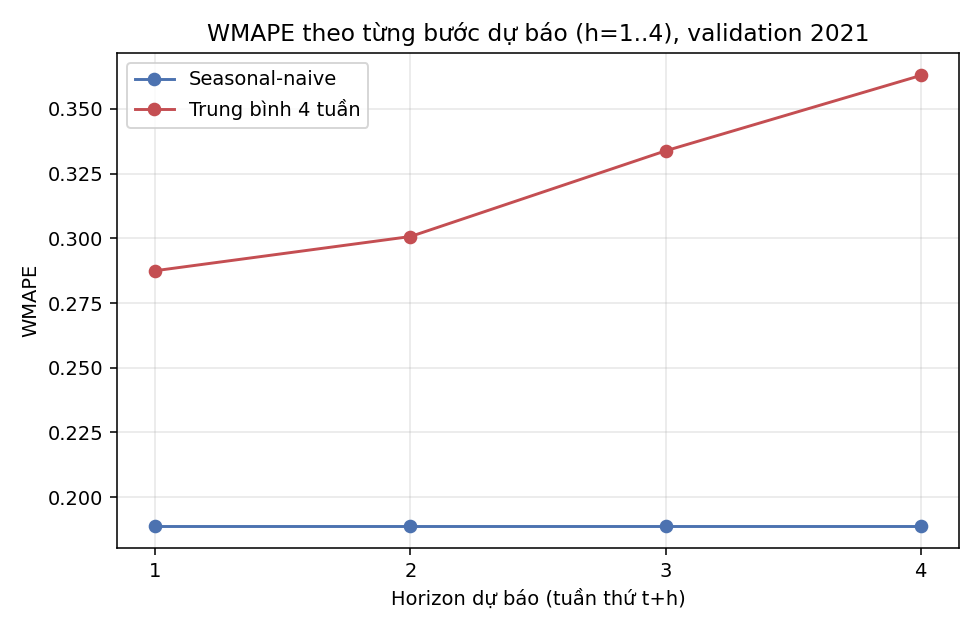

{
  "quy_tac": "train <= 2020-12-31, validation = năm 2021, test = năm 2022 (chia theo thời gian, không xáo trộn)",
  "train": {
    "so_tuan": 443,
    "tu_ngay": "2012-07-09",
    "den_ngay": "2020-12-28",
    "so_mau": 1772
  },
  "validation": {
    "so_tuan": 52,
    "tu_ngay": "2021-01-04",
    "den_ngay": "2021-12-27",
    "so_mau": 208
  },
  "test": {
    "so_tuan": 51,
    "tu_ngay": "2022-01-03",
    "den_ngay": "2022-12-19",
    "so_mau": 204
  }
}
{
  "so_mau": 832,
  "seasonal_naive": {
    "WMAPE": 0.189,
    "MAE": 819889.26
  },
  "trung_binh_4_tuan": {
    "WMAPE": 0.3212,
    "MAE": 1393087.76
  }
}


In [ ]:
mau_danh_muc = {"Streetwear": "#4C72B0", "Outdoor": "#55A868", "Casual": "#C44E52", "GenZ": "#8172B2"}

def dinh_dang_trieu(x, pos):
    return f"{x/1e6:,.0f}tr"

# Biểu đồ 1: chuỗi doanh thu tuần theo danh mục (2012-2022), có đánh dấu train/val/test
fig, ax = plt.subplots(figsize=(13, 5))
for c in danh_muc:
    ax.plot(pivot.index, pivot[c], label=c, color=mau_danh_muc.get(c), linewidth=1.1)
ax.axvline(MOC_TRAIN, color="gray", linestyle="--", linewidth=1)
ax.axvline(pd.Timestamp("2021-12-31"), color="gray", linestyle="--", linewidth=1)
ax.text(pd.Timestamp("2016-06-01"), pivot.values.max()*0.92, "TRAIN", ha="center", color="gray")
ax.text(pd.Timestamp("2021-06-15"), pivot.values.max()*0.92, "VAL\n2021", ha="center", color="gray")
ax.text(pd.Timestamp("2022-06-15"), pivot.values.max()*0.92, "TEST\n2022", ha="center", color="gray")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(dinh_dang_trieu))
ax.set_title("Doanh thu theo tuần cho từng danh mục (2012-2022) và ranh giới chia dữ liệu")
ax.set_xlabel("Tuần"); ax.set_ylabel("Doanh thu (triệu)")
ax.legend(loc="upper left"); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "bieu_do_1_chuoi_tuan_theo_danh_muc.png"), dpi=140)
display(Image(filename=os.path.join(OUT_DIR, "bieu_do_1_chuoi_tuan_theo_danh_muc.png")))
plt.show()

# Biểu đồ 2: tỷ trọng doanh thu theo danh mục (pie)
ty_trong = {c: ev["viec_3_chuoi_tuan"]["thong_ke_theo_danh_muc"][c]["ty_trong_doanh_thu_phan_tram"] for c in danh_muc}
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(ty_trong.values(), labels=[f"{c}\n{v}%" for c, v in ty_trong.items()],
       colors=[mau_danh_muc.get(c) for c in ty_trong], startangle=90,
       wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax.set_title("Tỷ trọng doanh thu theo danh mục (toàn bộ 2012-2022)")
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "bieu_do_2_ty_trong_danh_muc.png"), dpi=140)
display(Image(filename=os.path.join(OUT_DIR, "bieu_do_2_ty_trong_danh_muc.png")))
plt.show()

# Biểu đồ 3: so sánh WMAPE 2 baseline - tổng thể và theo danh mục
cats_for_chart = danh_muc + ["Tổng thể"]
sn_vals = [ev["viec_3_baseline_validation_2021"]["theo_danh_muc"][c]["seasonal_naive"]["WMAPE"] for c in danh_muc] \
          + [ev["viec_3_baseline_validation_2021"]["tong_the"]["seasonal_naive"]["WMAPE"]]
ma_vals = [ev["viec_3_baseline_validation_2021"]["theo_danh_muc"][c]["trung_binh_4_tuan"]["WMAPE"] for c in danh_muc] \
          + [ev["viec_3_baseline_validation_2021"]["tong_the"]["trung_binh_4_tuan"]["WMAPE"]]
x = np.arange(len(cats_for_chart)); w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, sn_vals, w, label="Seasonal-naive (cùng kỳ năm trước)", color="#4C72B0")
b2 = ax.bar(x + w/2, ma_vals, w, label="Trung bình 4 tuần gần nhất", color="#C44E52")
ax.set_xticks(x); ax.set_xticklabels(cats_for_chart)
ax.set_ylabel("WMAPE (thấp hơn = tốt hơn)")
ax.set_title("So sánh WMAPE 2 baseline trên tập validation 2021")
ax.bar_label(b1, fmt="%.3f", fontsize=8, padding=2)
ax.bar_label(b2, fmt="%.3f", fontsize=8, padding=2)
ax.legend(); ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "bieu_do_3_so_sanh_baseline_wmape.png"), dpi=140)
display(Image(filename=os.path.join(OUT_DIR, "bieu_do_3_so_sanh_baseline_wmape.png")))
plt.show()

# Biểu đồ 4: WMAPE seasonal-naive theo horizon (ổn định) so với trung bình 4 tuần (tệ dần)
horizons = [1, 2, 3, 4]
sn_h = [ev["viec_3_baseline_validation_2021"]["theo_horizon"][f"h{h}"]["seasonal_naive"]["WMAPE"] for h in horizons]
ma_h = [ev["viec_3_baseline_validation_2021"]["theo_horizon"][f"h{h}"]["trung_binh_4_tuan"]["WMAPE"] for h in horizons]
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(horizons, sn_h, marker="o", label="Seasonal-naive", color="#4C72B0")
ax.plot(horizons, ma_h, marker="o", label="Trung bình 4 tuần", color="#C44E52")
ax.set_xticks(horizons); ax.set_xlabel("Horizon dự báo (tuần thứ t+h)"); ax.set_ylabel("WMAPE")
ax.set_title("WMAPE theo từng bước dự báo (h=1..4), validation 2021")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "bieu_do_4_wmape_theo_horizon.png"), dpi=140)
display(Image(filename=os.path.join(OUT_DIR, "bieu_do_4_wmape_theo_horizon.png")))
plt.show()

print(json.dumps(ev["viec_3_chuoi_tuan"]["chia_du_lieu"], indent=2, ensure_ascii=False))
print(json.dumps(ev["viec_3_baseline_validation_2021"]["tong_the"], indent=2, ensure_ascii=False))